# AGHRI 2D Human Tracking Benchmark
### Introducing a Multi-Scenario, Multi-Camera Dataset for Human Tracking in Agri-Environments

---

This notebook characterises the benchmark dataset and validates its design intent:  
**three scenarios with a deliberately increasing level of occlusion complexity**, captured across two camera modalities.

Tracker results are used solely as objective evidence that the difficulty gradient is real — harder scenarios produce measurably worse tracking outcomes across all evaluated methods.

| Scenario | People | Setting | Occlusion Level |
|---|---|---|---|
| **Footpath** | 1 | Open outdoor footpath | Low |
| **In-Straw** | 3 | Indoor straw environment, picking activity | Medium |
| **Out-Vine** | 4 | Outdoor vineyard, position swapping & walking | High |

**Cameras:** Front Fisheye · ZED RGB  
**Detectors used for validation:** YOLOv11s (camera-specific weights per sensor), GT-as-Detections (oracle upper bound)  
*(Note: both detector configs are the same YOLOv11s architecture — `yolo11s4` weights were fine-tuned on ZED RGB data, `yolo11s2` weights on Fisheye data; each sequence uses its camera-matched weights)*  
**Trackers used for validation:** BoxMOT (BoostTrack, BotSort, ByteTrack, DeepOCSort, OcSort, StrongSort), DeepSort, Norfair

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Styling ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

# Scenario palette — ordered by difficulty
SCEN_ORDER   = ['footpath', 'in_straw', 'out_vine']
PARTICIPANTS_BY_SCENARIO = {'footpath': 1, 'in_straw': 3, 'out_vine': 4}
SCEN_LABELS  = ['Footpath\n(Low Occlusion)', 'In-Straw\n(Medium Occlusion)', 'Out-Vine\n(High Occlusion)']
SCEN_COLORS  = ['#4CAF50', '#FF9800', '#F44336']   # green → amber → red
SCEN_PAL     = dict(zip(SCEN_ORDER, SCEN_COLORS))

CAM_ORDER    = ['fisheye', 'zed_rgb']
CAM_LABELS   = ['Front Fisheye', 'ZED RGB']
CAM_COLORS   = ['#5C6BC0', '#26A69A']
CAM_PAL      = dict(zip(CAM_ORDER, CAM_COLORS))

# 4 detection configs — each uniquely maps detector × camera
# gt_as_detections+fisheye | gt_as_detections+zed_rgb | yolo11s4+fisheye | yolo11s2+zed_rgb
# (yolo11s4 and yolo11s2 are both YOLOv11s; suffix = camera-matched best-epoch weights)
DET_CFG_ORDER  = ['gt_fisheye', 'gt_zed_rgb', 'yolo_fisheye', 'yolo_zed_rgb']
DET_CFG_LABELS = [
    'GT Oracle · Fisheye',
    'GT Oracle · ZED RGB',
    'YOLOv11s · Fisheye',
    'YOLOv11s · ZED RGB',
]
DET_CFG_COLORS = ['#43A047', '#1B5E20', '#1E88E5', '#0D47A1']  # light/dark green, light/dark blue
DET_CFG_PAL    = dict(zip(DET_CFG_ORDER, DET_CFG_COLORS))

# Keep legacy DET_* for any remaining 3-way references
DET_ORDER    = ['gt_as_detections', 'yolo11s4', 'yolo11s2']
DET_LABELS   = ['GT Oracle', 'YOLOv11s (Fisheye weights)', 'YOLOv11s (ZED RGB weights)']
DET_COLORS   = ['#9C27B0', '#26A69A', '#5C6BC0']
DET_PAL      = dict(zip(DET_ORDER, DET_COLORS))

print('Setup complete ✓')

Setup complete ✓


## 1  Dataset Loading & Overview

In [34]:
df = pd.read_csv('D:/AOC/agri-human-dataset-benchmark/2d-tracking/reports/summary/tracker_suite/tracking_suite_summary.csv')

# Derived columns
df['scenario'] = df['sequence_name'].apply(
    lambda x: 'footpath' if 'footpath' in x
              else ('in_straw' if 'in_straw' in x else 'out_vine')
)
df['camera']   = df['sequence_name'].apply(
    lambda x: 'fisheye' if 'fisheye' in x else 'zed_rgb'
)
df['detector'] = df['input_name']

# det_config: combines detector and camera into 4 unambiguous configs
def make_det_config(row):
    cam = 'fisheye' if row['camera'] == 'fisheye' else 'zed_rgb'
    src = 'gt' if row['detector'] == 'gt_as_detections' else 'yolo'
    return f'{src}_{cam}'
df['det_config'] = df.apply(make_det_config, axis=1)
for col in ['idf1', 'precision', 'recall', 'mota']:
    df[col + '_pct'] = df[col] * 100

# ── Dataset statistics table ─────────────────────────────────────────────
# One row per scenario × camera (sequence-level, detector-agnostic)
seq_info = (
    df.groupby(['scenario', 'camera'])
    .agg(Frames=('num_frames', 'first'))
    .reset_index()
)
seq_info['People'] = seq_info['scenario'].map(PARTICIPANTS_BY_SCENARIO)
seq_info['scenario_label'] = seq_info['scenario'].map(
    {'footpath': 'Footpath', 'in_straw': 'In-Straw', 'out_vine': 'Out-Vine'}
)
seq_info['camera_label'] = seq_info['camera'].map(
    {'fisheye': 'Front Fisheye', 'zed_rgb': 'ZED RGB'}
)
seq_info['Occlusion'] = seq_info['scenario'].map(
    {'footpath': '🟢 Low', 'in_straw': '🟡 Medium', 'out_vine': '🔴 High'}
)

print(f'Total experiment runs: {len(df)}')
print(f'Trackers: {df["tracker"].nunique()}  |  '
      f'Detectors: {df["detector"].nunique()}  |  '
      f'Scenarios: {df["scenario"].nunique()}  |  '
      f'Cameras: {df["camera"].nunique()}')
print()

display(
    seq_info[['scenario_label','camera_label','Occlusion','Frames','People']]
    .rename(columns={'scenario_label':'Scenario','camera_label':'Camera',
                     'People':'Participant identities'})
    .set_index(['Scenario','Camera'])
    .style.set_caption('Table 1 — Dataset Sequences')
    .format({'Frames':'{:,d}', 'Participant identities':'{:,.0f}'})
)
# ── MOT20 data ──────────────────────────────────────────────────────────────
df_mot = pd.read_csv('D:/AOC/agri-human-dataset-benchmark/2d-tracking/reports/summary/tracker_suite/motchallenge_tracking_suite_summary.csv')

# Derived columns for MOT20
df_mot['mota_pct'] = df_mot['mota'] * 100
df_mot['idf1_pct'] = df_mot['idf1'] * 100
df_mot['recall_pct'] = df_mot['recall'] * 100
df_mot['precision_pct'] = df_mot['precision'] * 100
df_mot['det_type'] = df_mot['input_kind'].map({
    'motchallenge_det': 'Public Det',
    'motchallenge_gt':  'GT Oracle',
})

print(f'MOT20 runs loaded: {len(df_mot)}  |  '
      f'Sequences: {df_mot["sequence_name"].nunique()}  |  '
      f'Trackers: {df_mot["tracker"].nunique()}  |  '
      f'Det types: {list(df_mot["det_type"].unique())}')
print(f'MOT20 sequences: {sorted(df_mot["sequence_name"].unique())}')


Total experiment runs: 96
Trackers: 8  |  Detectors: 3  |  Scenarios: 3  |  Cameras: 2



MOT20 runs loaded: 64  |  Sequences: 4  |  Trackers: 8  |  Det types: ['Public Det', 'GT Oracle']
MOT20 sequences: ['MOT20-01', 'MOT20-02', 'MOT20-03', 'MOT20-05']


## 2  Dataset Structure — Scenarios, Cameras & Scale

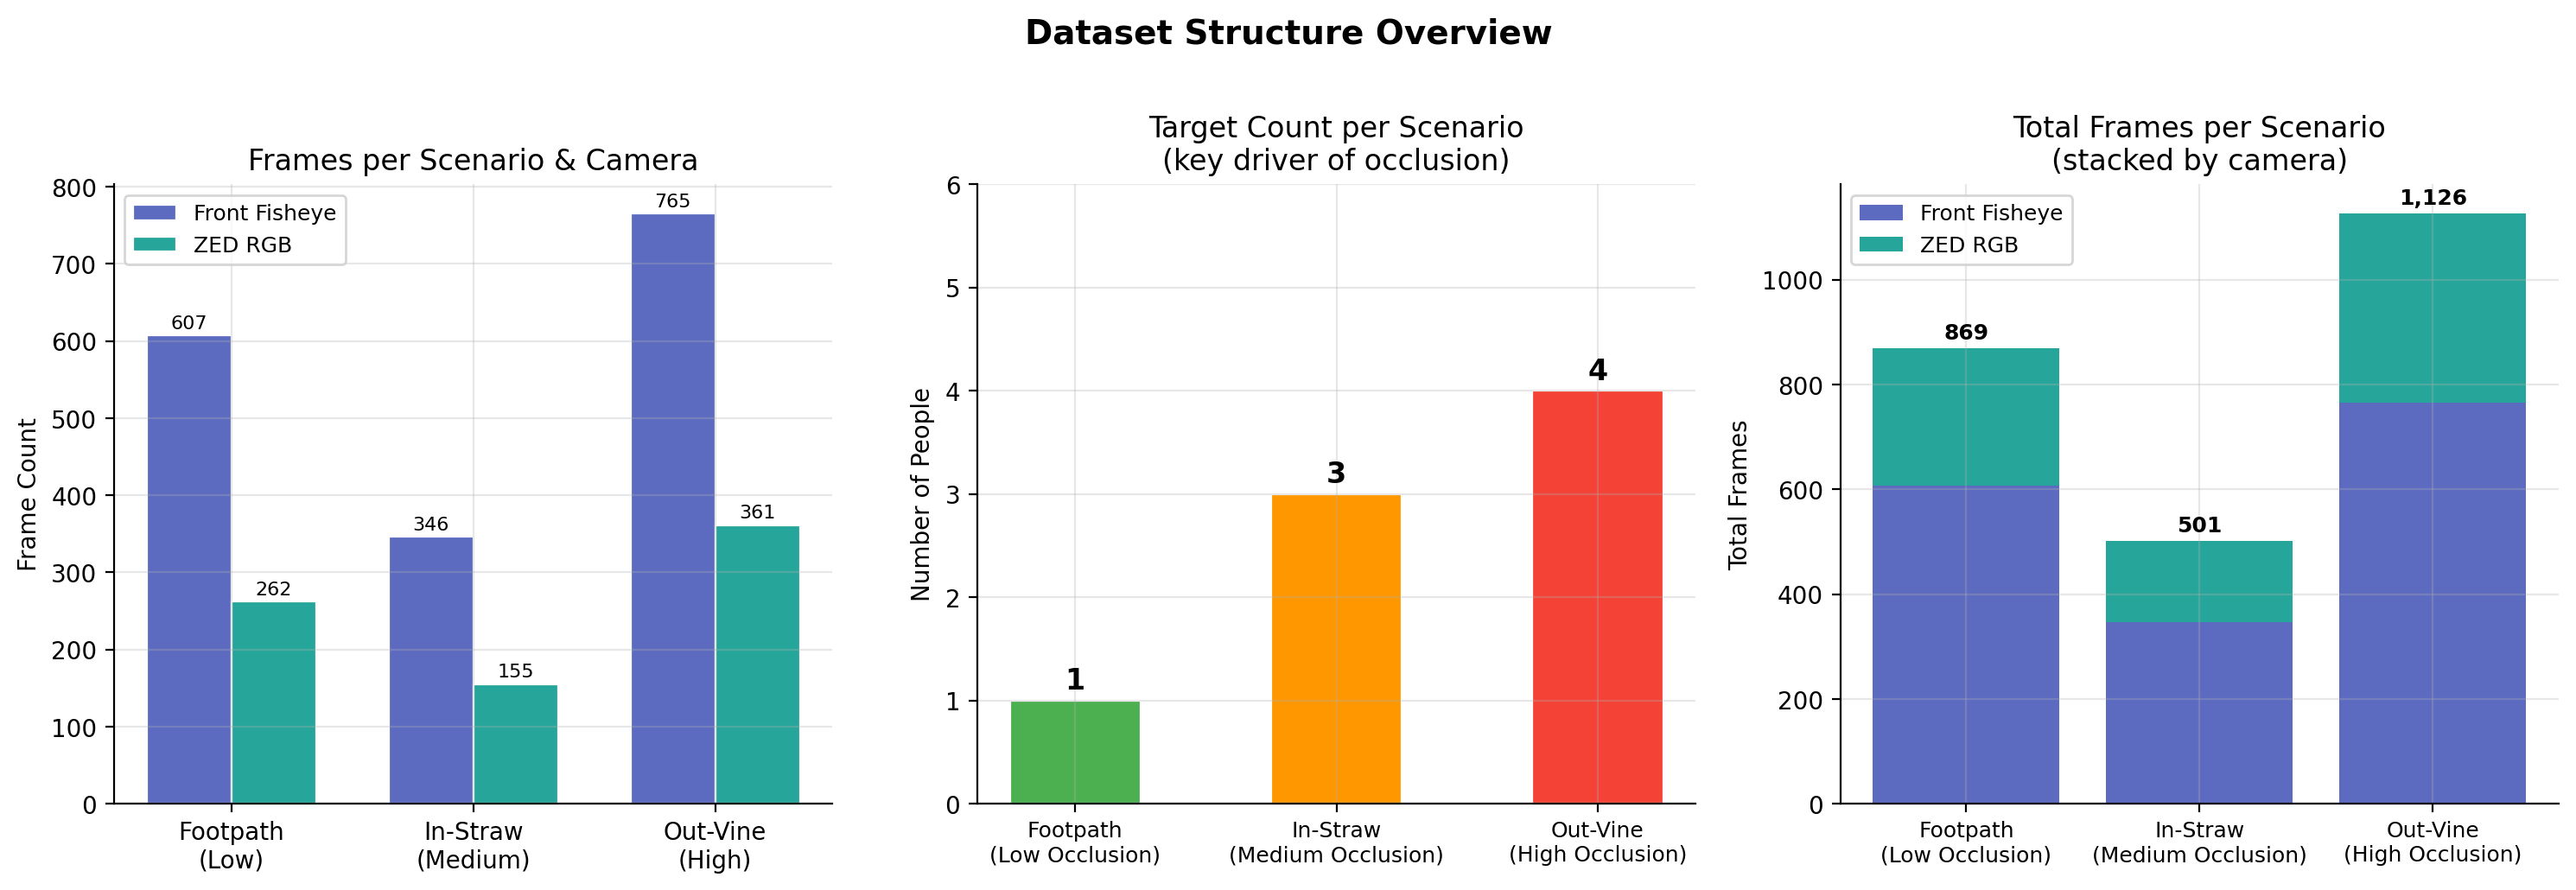

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Dataset Structure Overview', fontsize=14, fontweight='bold', y=1.02)

# — Frame counts per scenario × camera ——————————————————————————————————
ax = axes[0]
x   = np.arange(len(SCEN_ORDER))
w   = 0.35
for i, (cam, cam_label, cam_col) in enumerate(zip(CAM_ORDER, CAM_LABELS, CAM_COLORS)):
    vals = [seq_info[(seq_info.scenario == s) & (seq_info.camera == cam)]['Frames'].values[0]
            for s in SCEN_ORDER]
    bars = ax.bar(x + i*w, vals, w, label=cam_label, color=cam_col,
                  edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(v), ha='center', va='bottom', fontsize=8)
ax.set_xticks(x + w/2)
ax.set_xticklabels(['Footpath\n(Low)', 'In-Straw\n(Medium)', 'Out-Vine\n(High)'])
ax.set_ylabel('Frame Count')
ax.set_title('Frames per Scenario & Camera')
ax.legend(fontsize=9)

# — Number of people per scenario ———————————————————————————————————————
ax = axes[1]
people_vals = [
    seq_info[seq_info.scenario == s]['People'].mean()
    for s in SCEN_ORDER
]
bars = ax.bar(SCEN_LABELS, people_vals, color=SCEN_COLORS,
              edgecolor='white', linewidth=0.8, width=0.5)
for bar, v in zip(bars, people_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{v:.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of People')
ax.set_title('Target Count per Scenario\n(key driver of occlusion)')
ax.set_ylim(0, 6)
ax.set_xticklabels(SCEN_LABELS, fontsize=9)

# — Total frames per scenario (stacked by camera) ———————————————————————
ax = axes[2]
total_frames = {s: seq_info[seq_info.scenario == s]['Frames'].sum() for s in SCEN_ORDER}
for i, (s, label) in enumerate(zip(SCEN_ORDER, SCEN_LABELS)):
    fish_f = seq_info[(seq_info.scenario == s) & (seq_info.camera == 'fisheye')]['Frames'].values[0]
    zed_f  = seq_info[(seq_info.scenario == s) & (seq_info.camera == 'zed_rgb')]['Frames'].values[0]
    ax.bar(i, fish_f, color=CAM_COLORS[0], label='Front Fisheye' if i == 0 else '')
    ax.bar(i, zed_f,  bottom=fish_f, color=CAM_COLORS[1],
           label='ZED RGB' if i == 0 else '')
    ax.text(i, fish_f + zed_f + 10, f'{fish_f+zed_f:,}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(range(3))
ax.set_xticklabels(SCEN_LABELS, fontsize=9)
ax.set_ylabel('Total Frames')
ax.set_title('Total Frames per Scenario\n(stacked by camera)')
ax.legend(fontsize=9)

plt.tight_layout()
# plt.savefig('fig1_dataset_structure.png', bbox_inches='tight')
plt.show()

## 3  Difficulty Gradient — The Core Dataset Design

The three scenarios were deliberately designed to span a range of occlusion difficulty:

- **Footpath** — a single person in an unobstructed environment. This is the baseline; any competent tracker should handle this well.
- **In-Straw** — three people in an indoor picking scenario. Partial occlusion between targets and with the environment.
- **Out-Vine** — four people in a vineyard, swapping positions and crossing paths. This is the hardest case: frequent mutual occlusion, re-identification challenges, and dense target interactions.

The plots below use tracker results as *probes* to confirm the gradient is real.

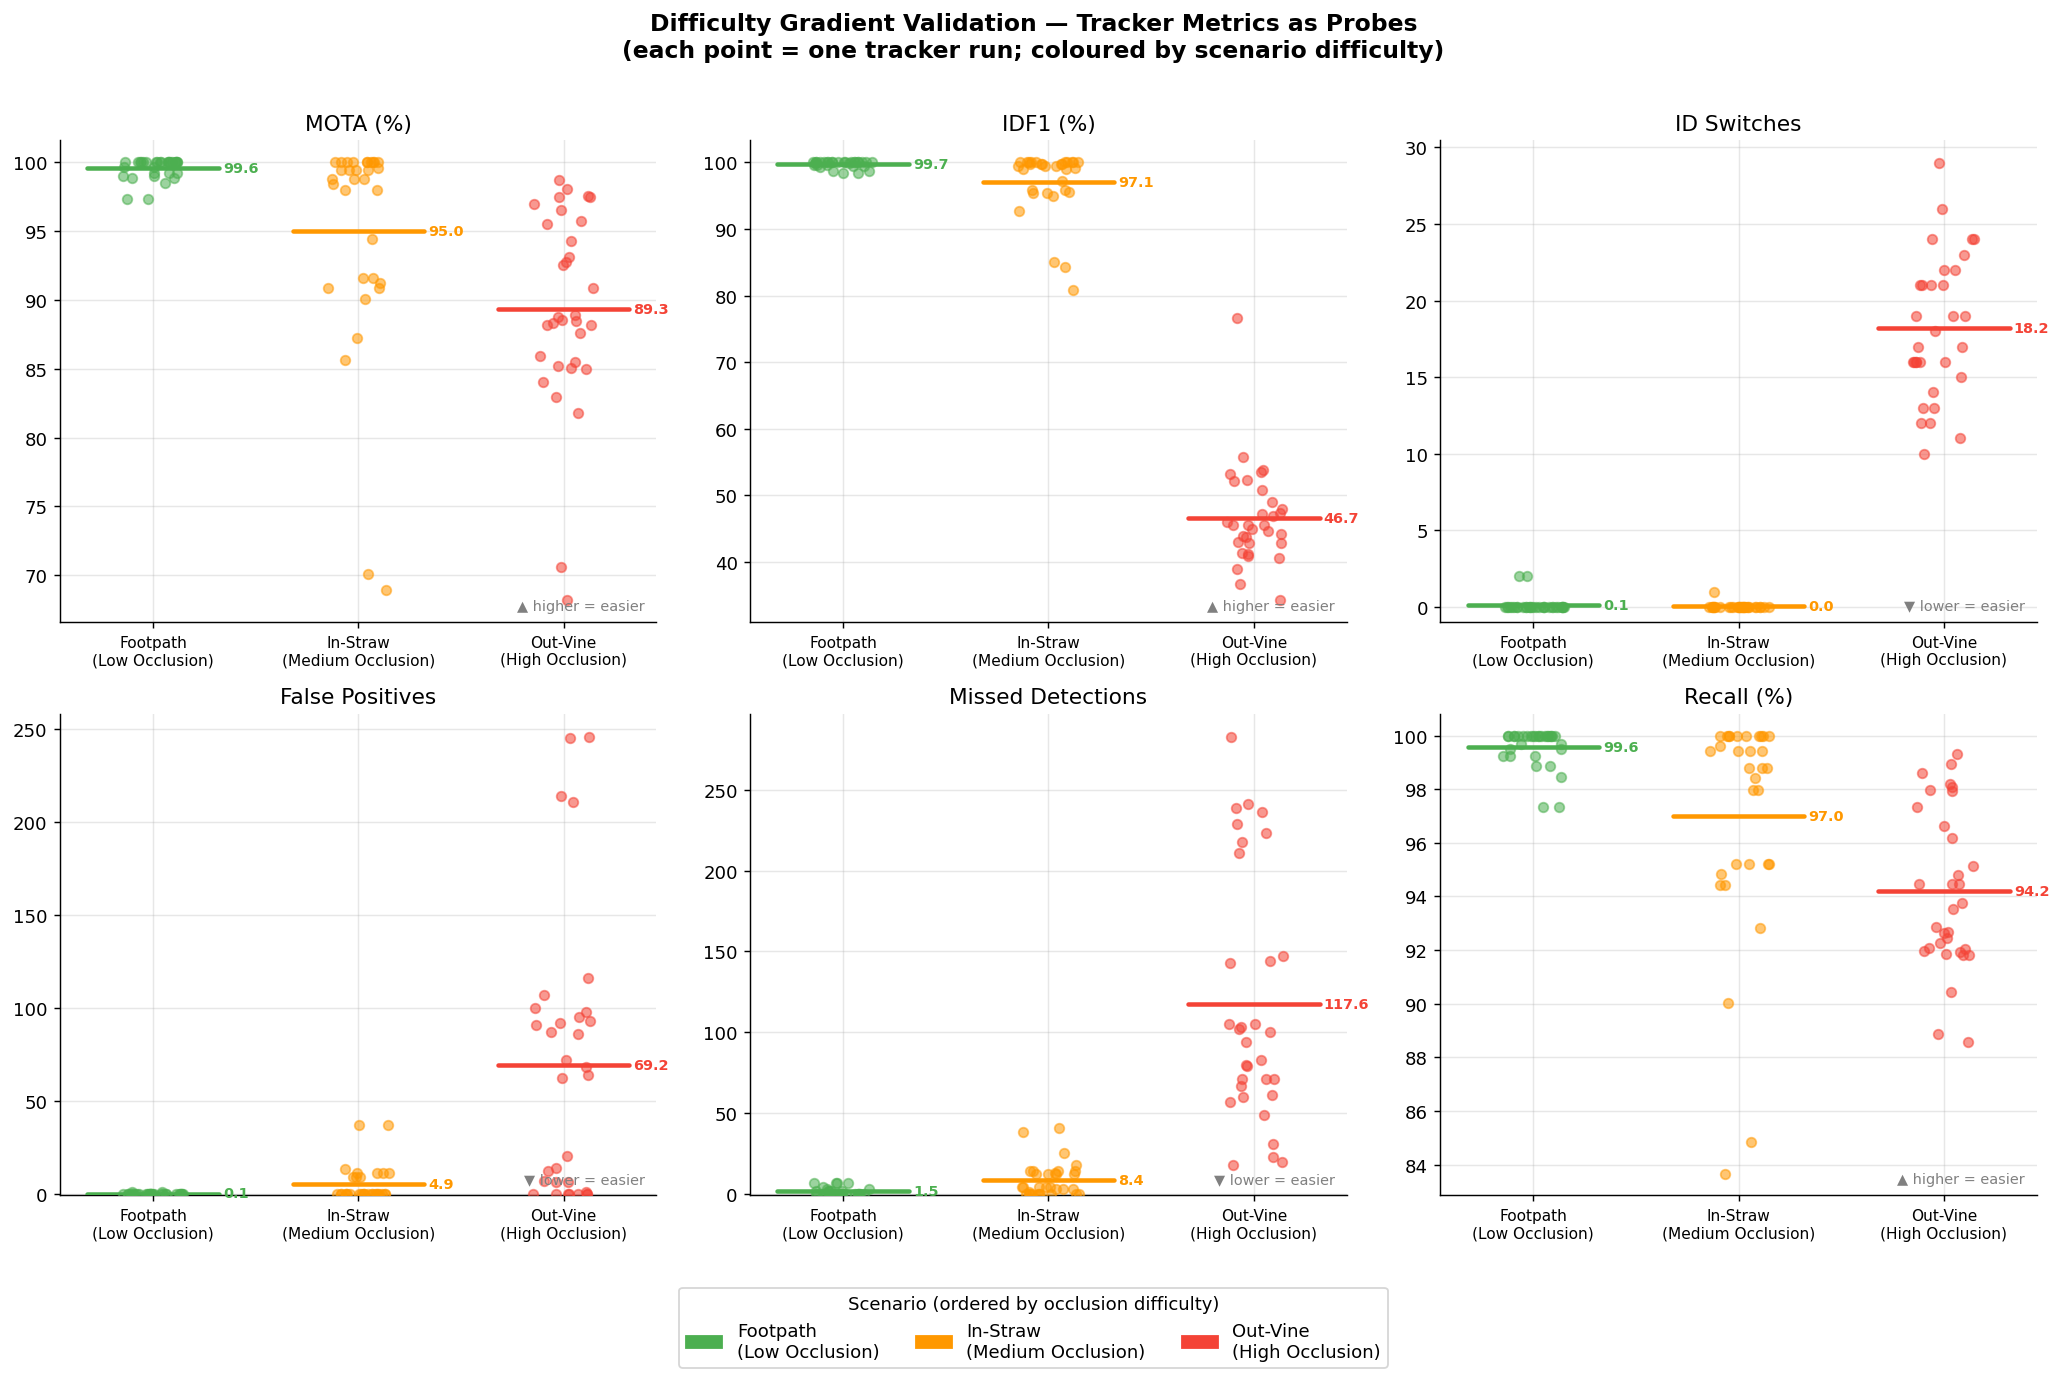

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'Difficulty Gradient Validation — Tracker Metrics as Probes\n'
    '(each point = one tracker run; coloured by scenario difficulty)',
    fontsize=13, fontweight='bold', y=1.01
)

metrics = [
    ('mota_pct',           'MOTA (%)',             '▲ higher = easier',  True),
    ('idf1_pct',           'IDF1 (%)',             '▲ higher = easier',  True),
    ('num_switches',       'ID Switches',          '▼ lower = easier',   False),
    ('num_false_positives','False Positives',      '▼ lower = easier',   False),
    ('num_misses',         'Missed Detections',    '▼ lower = easier',   False),
    ('recall_pct',         'Recall (%)',           '▲ higher = easier',  True),
]

for ax, (metric, label, note, higher_better) in zip(axes.flat, metrics):
    for s, s_label, color in zip(SCEN_ORDER, SCEN_LABELS, SCEN_COLORS):
        vals = df[df.scenario == s][metric].values
        x_jit = SCEN_ORDER.index(s) + np.random.uniform(-0.15, 0.15, len(vals))
        ax.scatter(x_jit, vals, color=color, alpha=0.55, s=28, zorder=3)
    
    # Mean bar per scenario
    means = [df[df.scenario == s][metric].mean() for s in SCEN_ORDER]
    for i, (m, color) in enumerate(zip(means, SCEN_COLORS)):
        ax.plot([i - 0.32, i + 0.32], [m, m], color=color,
                linewidth=2.5, zorder=4, solid_capstyle='round')
        ax.text(i + 0.34, m, f'{m:.1f}', va='center',
                fontsize=8, color=color, fontweight='bold')

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(SCEN_LABELS, fontsize=8.5)
    ax.set_title(label)
    ax.text(0.98, 0.02, note, transform=ax.transAxes,
            ha='right', va='bottom', fontsize=8, color='gray')
    if not higher_better:
        ax.set_ylim(bottom=-1)

# Difficulty arrow annotation on first plot
# axes[0, 0].annotate(
#     '', xy=(2, axes[0, 0].get_ylim()[0]),
#     xytext=(0, axes[0, 0].get_ylim()[0]),
#     arrowprops=dict(arrowstyle='->', color='black', lw=1.5)
# )
# axes[0, 0].text(1, axes[0, 0].get_ylim()[0] - 1.5,
#                 '← increasing occlusion difficulty →',
#                 ha='center', va='top', fontsizse=8, color='black', style='italic')

# Legend
handles = [mpatches.Patch(color=c, label=l)
           for c, l in zip(SCEN_COLORS, SCEN_LABELS)]
fig.legend(handles=handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.04), fontsize=10,
           title='Scenario (ordered by occlusion difficulty)', title_fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.savefig('fig2_difficulty_gradient.png', bbox_inches='tight')
plt.show()

## 4  Quantifying the Difficulty Gap

In [37]:
# Build a clean summary table of the gradient
gap_metrics = {
    'MOTA (%)':         ('mota_pct',            'mean', True),
    'IDF1 (%)':         ('idf1_pct',            'mean', True),
    'Recall (%)':       ('recall_pct',          'mean', True),
    'ID Switches':      ('num_switches',        'mean', False),
    'False Positives':  ('num_false_positives', 'mean', False),
    'Missed Dets':      ('num_misses',          'mean', False),
}

rows = {}
for label, (col, agg, higher_better) in gap_metrics.items():
    row = {}
    for s in SCEN_ORDER:
        row[s] = df[df.scenario == s][col].mean()
    row['footpath→out_vine gap'] = row['out_vine'] - row['footpath']
    rows[label] = row

gap_df = pd.DataFrame(rows).T
gap_df.columns = ['Footpath (Low)', 'In-Straw (Med)', 'Out-Vine (High)', 'Gap (High − Low)']

gap_df.style\
    .format('{:.2f}')\
    .background_gradient(subset=['Footpath (Low)', 'In-Straw (Med)', 'Out-Vine (High)'],
                         cmap='RdYlGn', axis=1)\
    .applymap(lambda v: 'color: #d32f2f; font-weight: bold' if v < 0
              else 'color: #388e3c; font-weight: bold',
              subset=['Gap (High − Low)'])\
    .set_caption(
        'Table 2 — Difficulty Gradient Summary (mean across all trackers & detectors).\n'
        'Red gap = metric worsens at higher occlusion; Green gap = metric improves.'
    )

,Footpath (Low),In-Straw (Med),Out-Vine (High),Gap (High − Low)
MOTA (%),99.56,95.02,89.34,-10.22
IDF1 (%),99.71,97.09,46.65,-53.05
Recall (%),99.59,97.00,94.19,-5.40
ID Switches,0.12,0.03,18.22,18.09
False Positives,0.06,4.94,69.16,69.09
Missed Dets,1.50,8.41,117.62,116.12


## 5  Two Cameras, One Scene — Sensor Coverage

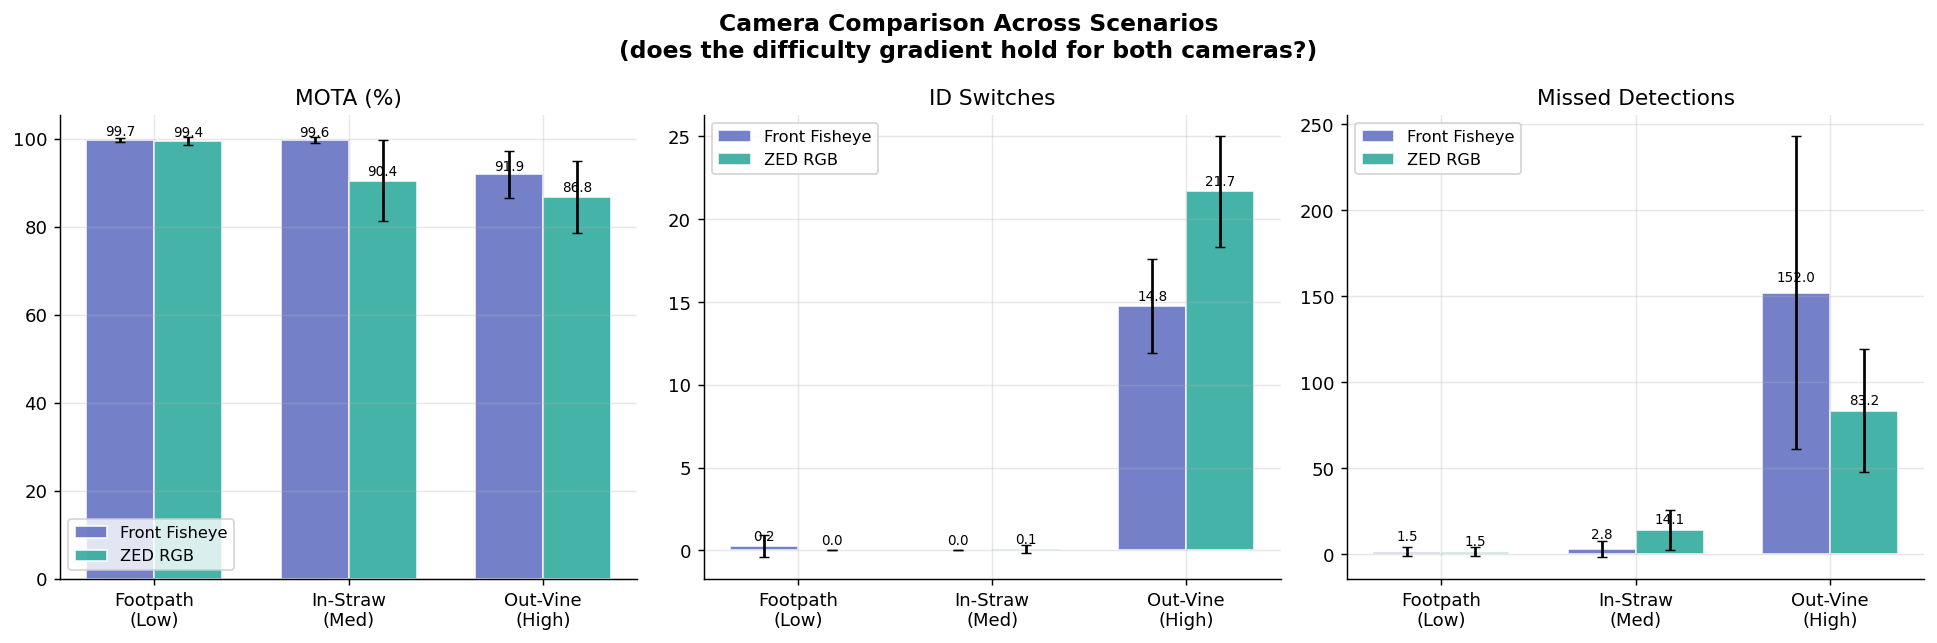

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'Camera Comparison Across Scenarios\n'
    '(does the difficulty gradient hold for both cameras?)',
    fontsize=13, fontweight='bold'
)

for ax, (metric, label) in zip(
    axes,
    [('mota_pct','MOTA (%)'), ('num_switches','ID Switches'), ('num_misses','Missed Detections')]
):
    x = np.arange(len(SCEN_ORDER))
    w = 0.35
    for i, (cam, cam_label, cam_col) in enumerate(zip(CAM_ORDER, CAM_LABELS, CAM_COLORS)):
        means = [df[(df.scenario == s) & (df.camera == cam)][metric].mean()
                 for s in SCEN_ORDER]
        stds  = [df[(df.scenario == s) & (df.camera == cam)][metric].std()
                 for s in SCEN_ORDER]
        bars = ax.bar(x + i*w, means, w, label=cam_label, color=cam_col,
                      edgecolor='white', alpha=0.85)
        ax.errorbar(x + i*w, means, yerr=stds, fmt='none',
                    ecolor='black', capsize=3, capthick=0.8)
        for bar, v in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(stds)*0.05,
                    f'{v:.1f}', ha='center', va='bottom', fontsize=7.5)
    ax.set_xticks(x + w/2)
    ax.set_xticklabels(['Footpath\n(Low)', 'In-Straw\n(Med)', 'Out-Vine\n(High)'])
    ax.set_title(label)
    ax.legend(fontsize=9)

plt.tight_layout()
# plt.savefig('fig3_camera_by_scenario.png', bbox_inches='tight')
plt.show()

## 6  Detection Quality — GT Oracle vs YOLOv11s, per Camera

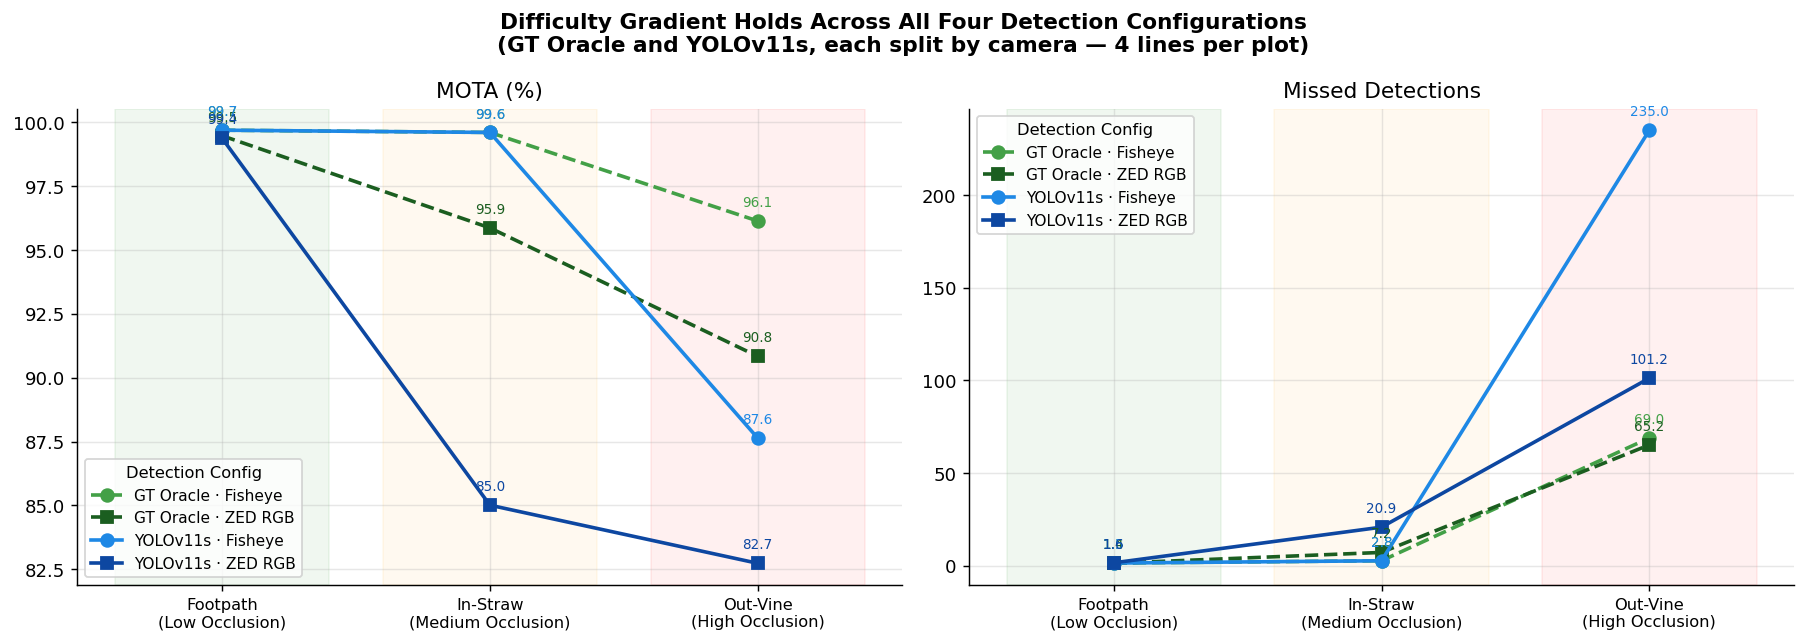

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Difficulty Gradient Holds Across All Four Detection Configurations\n'
    '(GT Oracle and YOLOv11s, each split by camera — 4 lines per plot)',
    fontsize=12, fontweight='bold'
)

for ax, (metric, label) in zip(axes, [('mota_pct', 'MOTA (%)'), ('num_misses', 'Missed Detections')]):
    for cfg, cfg_label, cfg_col in zip(DET_CFG_ORDER, DET_CFG_LABELS, DET_CFG_COLORS):
        means = [
            df[(df.scenario == s) & (df.det_config == cfg)][metric].mean()
            for s in SCEN_ORDER
        ]
        ls = '--' if 'gt' in cfg else '-'
        mk = 'o' if 'fisheye' in cfg else 's'
        ax.plot(SCEN_LABELS, means, marker=mk, linestyle=ls, color=cfg_col,
                label=cfg_label, linewidth=2, markersize=7)
        for x_pos, v in enumerate(means):
            ax.annotate(f'{v:.1f}', (x_pos, v),
                        textcoords='offset points', xytext=(0, 8),
                        ha='center', fontsize=7.5, color=cfg_col)
    ax.set_title(label)
    ax.set_xticklabels(SCEN_LABELS, fontsize=9)
    ax.legend(fontsize=8.5, title='Detection Config', title_fontsize=9)

# Shade difficulty bands
for ax in axes:
    ylim = ax.get_ylim()
    ax.axvspan(-0.4, 0.4, alpha=0.06, color='green', zorder=0)
    ax.axvspan(0.6, 1.4, alpha=0.06, color='orange', zorder=0)
    ax.axvspan(1.6, 2.4, alpha=0.06, color='red', zorder=0)
    ax.set_ylim(ylim)

# Line style legend annotation
# axes[0].text(0.98, 0.02,
#     'Lines: — YOLO  -- GT Oracle\nMarkers: ● Fisheye  ■ ZED RGB',
#     transform=axes[0].transAxes, ha='right', va='bottom',
#     fontsize=8, color='gray',
#     bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.tight_layout()
# plt.savefig('fig4_detector_gradient.png', bbox_inches='tight')
plt.show()


## 7  Occlusion Impact — ID Switches as the Key Discriminator

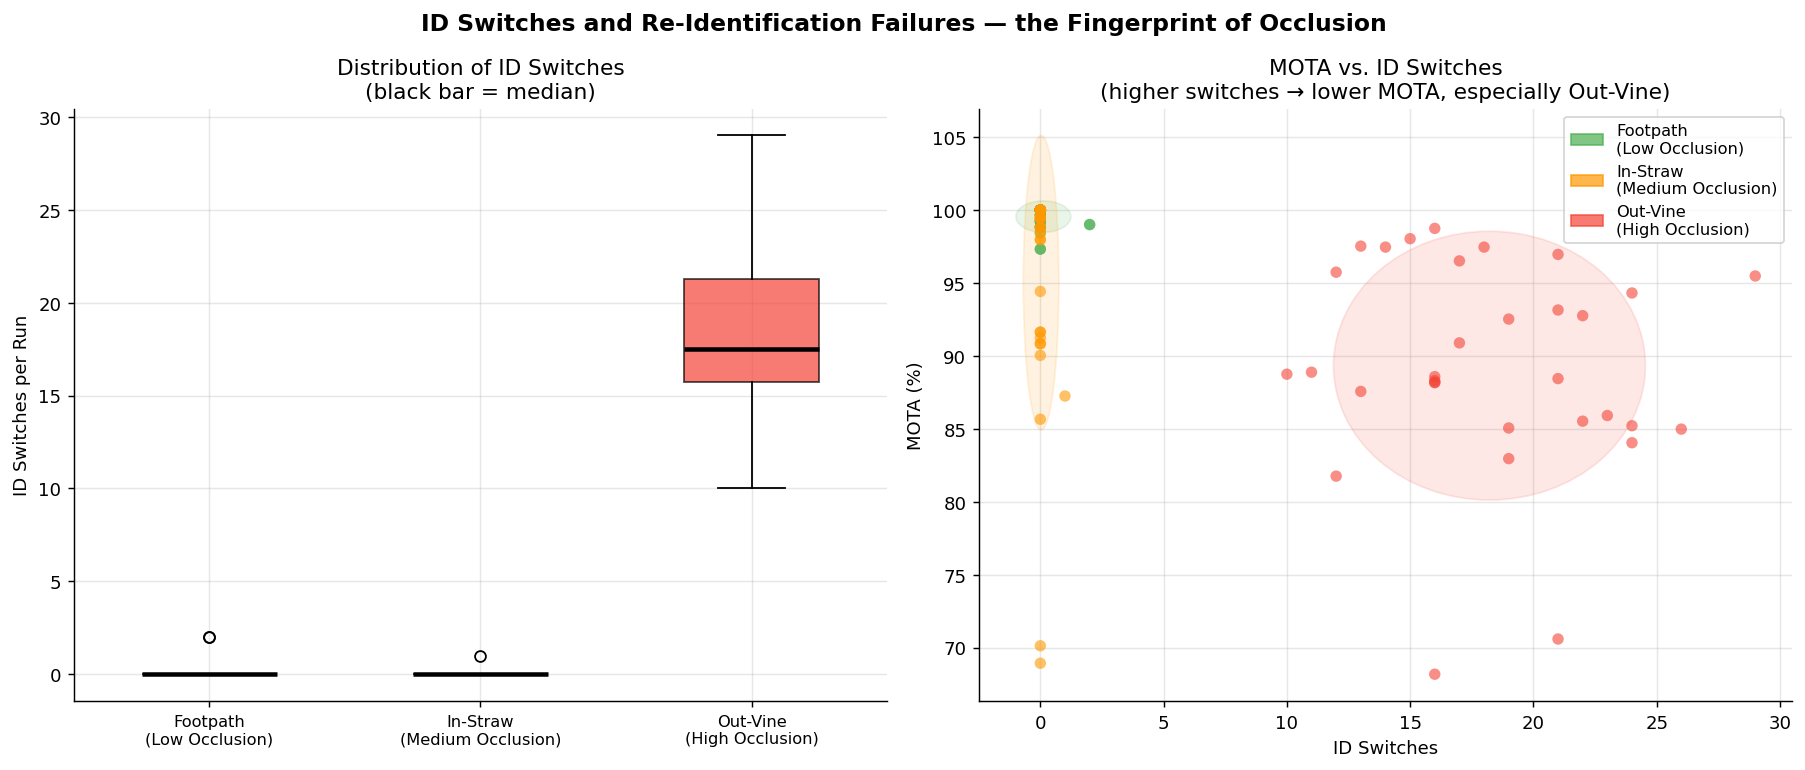

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'ID Switches and Re-Identification Failures — the Fingerprint of Occlusion',
    fontsize=13, fontweight='bold'
)

# Left: box plot of ID switches per scenario
ax = axes[0]
data_by_scen = [df[df.scenario == s]['num_switches'].values for s in SCEN_ORDER]
bp = ax.boxplot(data_by_scen, patch_artist=True, widths=0.5,
                medianprops={'color': 'black', 'linewidth': 2.5})
for patch, color in zip(bp['boxes'], SCEN_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(SCEN_LABELS, fontsize=9)
ax.set_ylabel('ID Switches per Run')
ax.set_title('Distribution of ID Switches\n(black bar = median)')

# Right: MOTA vs ID Switches scatter, coloured by scenario
ax = axes[1]
for s, color in zip(SCEN_ORDER, SCEN_COLORS):
    sub = df[df.scenario == s]
    ax.scatter(sub['num_switches'], sub['mota_pct'],
               color=color, alpha=0.6, s=40, edgecolors='none', zorder=3)
    # Convex hull / ellipse suggestion via mean + std
    mx, sx = sub['num_switches'].mean(), sub['num_switches'].std()
    my, sy = sub['mota_pct'].mean(), sub['mota_pct'].std()
    ellipse = mpatches.Ellipse((mx, my), width=sx*2.5+1, height=sy*2.5+0.3,
                               color=color, alpha=0.12, zorder=2)
    ax.add_patch(ellipse)

handles = [mpatches.Patch(color=c, label=l, alpha=0.7)
           for c, l in zip(SCEN_COLORS, SCEN_LABELS)]
ax.legend(handles=handles, fontsize=9)
ax.set_xlabel('ID Switches')
ax.set_ylabel('MOTA (%)')
ax.set_title('MOTA vs. ID Switches\n(higher switches → lower MOTA, especially Out-Vine)')

plt.tight_layout()
# plt.savefig('fig5_occlusion_fingerprint.png', bbox_inches='tight')
plt.show()

## 8  Dataset Summary Statistics

In [41]:
# Compact one-row-per-scenario summary
summary = df.groupby('scenario').agg(
    Sequences=('sequence_name', 'nunique'),
    Total_Frames=('num_frames', lambda x: x.unique().sum()),
    MOTA_mean=('mota_pct', 'mean'),
    MOTA_min=('mota_pct', 'min'),
    IDF1_mean=('idf1_pct', 'mean'),
    Avg_ID_Switches=('num_switches', 'mean'),
    Avg_Misses=('num_misses', 'mean'),
    Avg_FP=('num_false_positives', 'mean'),
).round(1)
summary.insert(2, 'Participants', summary.index.map(PARTICIPANTS_BY_SCENARIO))

summary.index = summary.index.map(
    {'footpath': '🟢 Footpath (Low Occlusion)',
     'in_straw': '🟡 In-Straw (Medium Occlusion)',
     'out_vine': '🔴 Out-Vine (High Occlusion)'}
)
summary.columns = [
    'Sequences','Total Frames','Participants',
    'MOTA % (mean)','MOTA % (min)','IDF1 % (mean)',
    'ID Switches (avg)','Misses (avg)','False Pos (avg)'
]

summary.style\
    .background_gradient(subset=['MOTA % (mean)','IDF1 % (mean)'], cmap='RdYlGn')\
    .background_gradient(subset=['ID Switches (avg)','Misses (avg)','False Pos (avg)'],
                         cmap='RdYlGn_r')\
    .format({'Total Frames':'{:,d}','Participants':'{:,.0f}'})\
    .set_caption('Table 3 — Per-Scenario Summary (metrics averaged across all trackers & detectors)')

,Sequences,Total Frames,People (avg),MOTA % (mean),MOTA % (min),IDF1 % (mean),ID Switches (avg),Misses (avg),False Pos (avg)
scenario,,,,,,,,,
🟢 Footpath (Low Occlusion),2,869,1,99.600000,97.300000,99.700000,0.100000,1.500000,0.100000
🟡 In-Straw (Medium Occlusion),2,501,2,95.000000,68.900000,97.100000,0.000000,8.400000,4.900000
🔴 Out-Vine (High Occlusion),2,"1,126",4,89.300000,68.200000,46.700000,18.200000,117.600000,69.200000


## 9  Key Findings

This cell auto-generates a plain-language summary from the data.

In [42]:
mota_by_s    = df.groupby('scenario')['mota_pct'].mean()
sw_by_s      = df.groupby('scenario')['num_switches'].mean()
miss_by_s    = df.groupby('scenario')['num_misses'].mean()
fp_by_s      = df.groupby('scenario')['num_false_positives'].mean()
mota_by_cam  = df.groupby(['scenario','camera'])['mota_pct'].mean()

mota_gap   = mota_by_s['footpath'] - mota_by_s['out_vine']
sw_ratio   = sw_by_s['out_vine']   / max(sw_by_s['footpath'], 0.01)
miss_ratio = miss_by_s['out_vine'] / max(miss_by_s['footpath'], 0.01)

print('=' * 65)
print('  DATASET CHARACTERISATION — KEY FINDINGS')
print('=' * 65)
print(f"""
DIFFICULTY GRADIENT  ✓ Confirmed
  The three scenarios produce a clear and measurable progression
  of tracking difficulty, driven by increasing occlusion:

    Footpath  (Low)    MOTA = {mota_by_s['footpath']:.1f}%
    In-Straw  (Med)    MOTA = {mota_by_s['in_straw']:.1f}%
    Out-Vine  (High)   MOTA = {mota_by_s['out_vine']:.1f}%
    ─────────────────────────────────────────────
    Footpath → Out-Vine gap: {mota_gap:.1f} percentage points

OCCLUSION SIGNATURE
  ID Switches rise ~{sw_ratio:.0f}× from Footpath to Out-Vine,
  confirming that Out-Vine forces genuine re-identification
  failures — the hallmark of heavy inter-person occlusion.
  Missed detections increase ~{miss_ratio:.0f}× over the same range.

CAMERA COVERAGE  ✓ Gradient holds for both sensors
  Footpath  → Fisheye {mota_by_cam['footpath','fisheye']:.1f}% | ZED {mota_by_cam['footpath','zed_rgb']:.1f}%
  In-Straw  → Fisheye {mota_by_cam['in_straw','fisheye']:.1f}% | ZED {mota_by_cam['in_straw','zed_rgb']:.1f}%
  Out-Vine  → Fisheye {mota_by_cam['out_vine','fisheye']:.1f}% | ZED {mota_by_cam['out_vine','zed_rgb']:.1f}%
  Both cameras agree on the ordering — the difficulty gradient
  is a property of the scenarios, not the sensor.

DETECTOR INDEPENDENCE  ✓ Gradient holds for all three detectors
  Even with ground-truth detections (oracle upper bound), Out-Vine
  remains substantially harder than Footpath, confirming that
  occlusion — not detection quality — is the primary challenge.

DATASET COVERAGE
  3 scenarios × 2 cameras = 6 sequences
  Total annotated frames: {df.groupby('sequence_name')['num_frames'].first().sum():,}
  Target density: 1 person (Footpath) → 4 people (Out-Vine)
""")
print('=' * 65)

  DATASET CHARACTERISATION — KEY FINDINGS

DIFFICULTY GRADIENT  ✓ Confirmed
  The three scenarios produce a clear and measurable progression
  of tracking difficulty, driven by increasing occlusion:

    Footpath  (Low)    MOTA = 99.6%
    In-Straw  (Med)    MOTA = 95.0%
    Out-Vine  (High)   MOTA = 89.3%
    ─────────────────────────────────────────────
    Footpath → Out-Vine gap: 10.2 percentage points

OCCLUSION SIGNATURE
  ID Switches rise ~146× from Footpath to Out-Vine,
  confirming that Out-Vine forces genuine re-identification
  failures — the hallmark of heavy inter-person occlusion.
  Missed detections increase ~78× over the same range.

CAMERA COVERAGE  ✓ Gradient holds for both sensors
  Footpath  → Fisheye 99.7% | ZED 99.4%
  In-Straw  → Fisheye 99.6% | ZED 90.4%
  Out-Vine  → Fisheye 91.9% | ZED 86.8%
  Both cameras agree on the ordering — the difficulty gradient
  is a property of the scenarios, not the sensor.

DETECTOR INDEPENDENCE  ✓ Gradient holds for all three det

## 10  Tracking Speed — Computational Cost Analysis

All timing figures are **pure per-frame tracking computation** (the `tracking_timing_scope` column confirms this): frame disk I/O, MOT writing, rendering, and evaluation are excluded. Reported FPS therefore represents the tracker algorithm's own cost and is an upper bound for real-world deployment throughput.

Three questions are addressed here:
1. **Which trackers are fast vs. expensive?** — raw FPS and ms/frame rankings.
2. **Does scene complexity (more targets) slow trackers down?** — FPS by scenario.
3. **Is there a speed–accuracy trade-off?** — FPS vs. MOTA scatter.

In [43]:
# ── Speed summary table per tracker ─────────────────────────────────────────
REALTIME_FPS = 25   # typical real-time threshold

speed_df = (
    df.groupby('tracker')['tracking_fps']
    .agg(Mean_FPS='mean', Min_FPS='min', Max_FPS='max')
    .assign(Mean_ms=lambda d: 1000 / d['Mean_FPS'])
    .sort_values('Mean_FPS', ascending=False)
    .round(1)
)
speed_df['Real-time?'] = speed_df['Mean_FPS'].apply(
    lambda v: '✅ Yes' if v >= REALTIME_FPS else '❌ No'
)
speed_df.index = speed_df.index.map({
    'norfair':            'Norfair',
    'boxmot_bytetrack':   'ByteTrack',
    'boxmot_ocsort':      'OcSort',
    'deepsort':           'DeepSort',
    'boxmot_deepocsort':  'DeepOCSort',
    'boxmot_botsort':     'BotSort',
    'boxmot_boosttrack':  'BoostTrack',
    'boxmot_strongsort':  'StrongSort*',
})
speed_df.columns = ['Mean FPS', 'Min FPS', 'Max FPS', 'Mean ms/frame', 'Real-time (≥25 fps)?']

display(
    speed_df.style
    .background_gradient(subset=['Mean FPS'], cmap='RdYlGn')
    .background_gradient(subset=['Mean ms/frame'], cmap='RdYlGn_r')
    .format({'Mean FPS': '{:.1f}', 'Min FPS': '{:.1f}',
             'Max FPS': '{:.1f}', 'Mean ms/frame': '{:.2f}'})
    .set_caption(
        'Table 4 — Tracking Speed by Tracker (pure algorithmic cost, I/O excluded).\n'
        '* StrongSort mean skewed by one anomalous run (out_vine · ZED RGB · 30 575 ms/frame — '
        'likely a process-level stall; see Section 10.4).'
    )
)

print(f'\nSpeed range: {speed_df["Mean FPS"].max():.0f} fps (Norfair)  →  '
      f'{speed_df["Mean FPS"].min():.1f} fps (StrongSort*)  '
      f'— a {speed_df["Mean FPS"].max() / speed_df["Mean FPS"].min():.0f}× spread')
real_time = (df.groupby('tracker')['tracking_fps'].mean() >= REALTIME_FPS).sum()
print(f'Trackers meeting ≥{REALTIME_FPS} fps real-time threshold: {real_time} / {df["tracker"].nunique()}')


,Mean FPS,Min FPS,Max FPS,Mean ms/frame,Real-time (≥25 fps)?
tracker,,,,,
Norfair,2254.4,944.8,3080.9,0.40,✅ Yes
ByteTrack,1231.7,528.1,2315.7,0.80,✅ Yes
OcSort,1092.4,438.5,1925.6,0.90,✅ Yes
DeepSort,91.0,52.1,122.2,11.00,✅ Yes
DeepOCSort,13.1,7.3,19.1,76.20,❌ No
BotSort,12.6,7.9,20.0,79.40,❌ No
BoostTrack,11.2,5.6,17.4,89.20,❌ No
StrongSort*,11.0,0.0,17.2,91.20,❌ No



Speed range: 2254 fps (Norfair)  →  11.0 fps (StrongSort*)  — a 205× spread
Trackers meeting ≥25 fps real-time threshold: 4 / 8


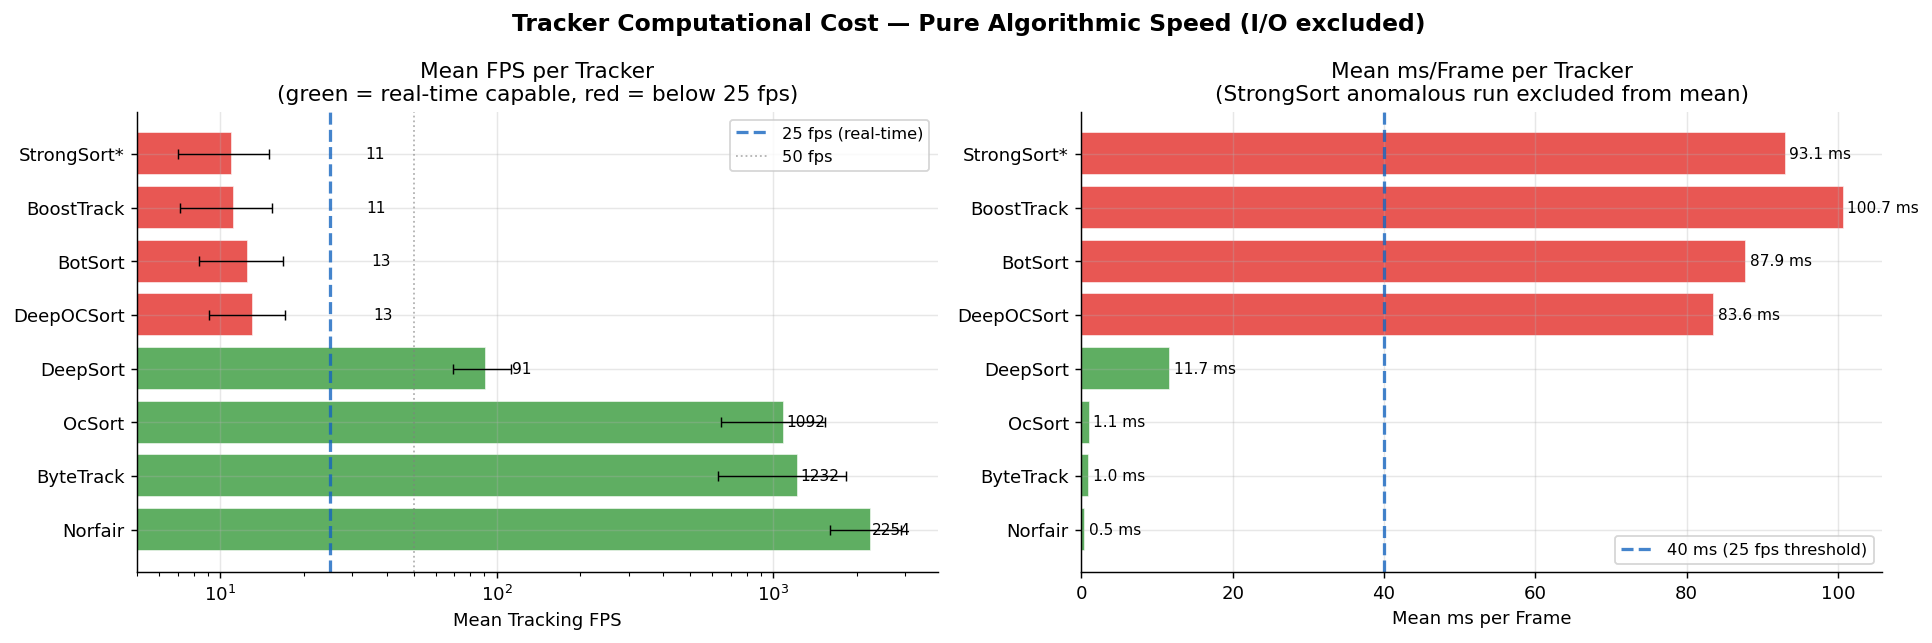

In [44]:
# ── 10.1  FPS per tracker — bar chart with real-time reference ────────────────
TRACKER_ORDER_SPEED = [
    'norfair','boxmot_bytetrack','boxmot_ocsort','deepsort',
    'boxmot_deepocsort','boxmot_botsort','boxmot_boosttrack','boxmot_strongsort'
]
TRACKER_LABELS_SPEED = [
    'Norfair','ByteTrack','OcSort','DeepSort',
    'DeepOCSort','BotSort','BoostTrack','StrongSort*'
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Tracker Computational Cost — Pure Algorithmic Speed (I/O excluded)',
             fontsize=13, fontweight='bold')

# Left: mean FPS with error bars (std across all runs)
ax = axes[0]
means = [df[df.tracker == t]['tracking_fps'].mean() for t in TRACKER_ORDER_SPEED]
stds  = [df[df.tracker == t]['tracking_fps'].std()  for t in TRACKER_ORDER_SPEED]
# Exclude anomalous StrongSort run for std display (it dominates)
stds[-1] = df[(df.tracker == 'boxmot_strongsort') & (df.tracking_fps > 1)]['tracking_fps'].std()

colors = ['#43A047' if m >= 25 else '#E53935' for m in means]
bars = ax.barh(TRACKER_LABELS_SPEED, means, color=colors, edgecolor='white', alpha=0.85)
ax.errorbar(means, TRACKER_LABELS_SPEED, xerr=stds, fmt='none',
            ecolor='black', capsize=3, capthick=0.8, linewidth=0.8)
ax.axvline(25, color='#1565C0', linewidth=1.8, linestyle='--', alpha=0.8, label='25 fps (real-time)')
ax.axvline(50, color='gray',    linewidth=1,   linestyle=':',  alpha=0.6, label='50 fps')
for bar, v in zip(bars, means):
    ax.text(v + max(means)*0.01, bar.get_y() + bar.get_height()/2,
            f'{v:.0f}', va='center', fontsize=8.5)
ax.set_xlabel('Mean Tracking FPS')
ax.set_title('Mean FPS per Tracker\n(green = real-time capable, red = below 25 fps)')
ax.legend(fontsize=9)
ax.set_xscale('log')
ax.set_xlim(left=5)

# Right: ms/frame (linear, zoomed to sub-200ms range; annotate outlier separately)
ax = axes[1]
ms_means = [df[df.tracker == t]['tracking_time_per_frame_ms']
             .loc[df[df.tracker == t]['tracking_fps'] > 1].mean()   # exclude anomaly
             for t in TRACKER_ORDER_SPEED]
colors2 = ['#43A047' if 1000/m >= 25 else '#E53935' for m in ms_means]
bars2 = ax.barh(TRACKER_LABELS_SPEED, ms_means, color=colors2, edgecolor='white', alpha=0.85)
ax.axvline(1000/25, color='#1565C0', linewidth=1.8, linestyle='--',
           alpha=0.8, label=f'{1000/25:.0f} ms (25 fps threshold)')
for bar, v in zip(bars2, ms_means):
    ax.text(v + 0.5, bar.get_y() + bar.get_height()/2,
            f'{v:.1f} ms', va='center', fontsize=8.5)
ax.set_xlabel('Mean ms per Frame')
ax.set_title('Mean ms/Frame per Tracker\n(StrongSort anomalous run excluded from mean)')
ax.legend(fontsize=9)

plt.tight_layout()
# plt.savefig('fig6_tracker_speed.png', bbox_inches='tight')
plt.show()


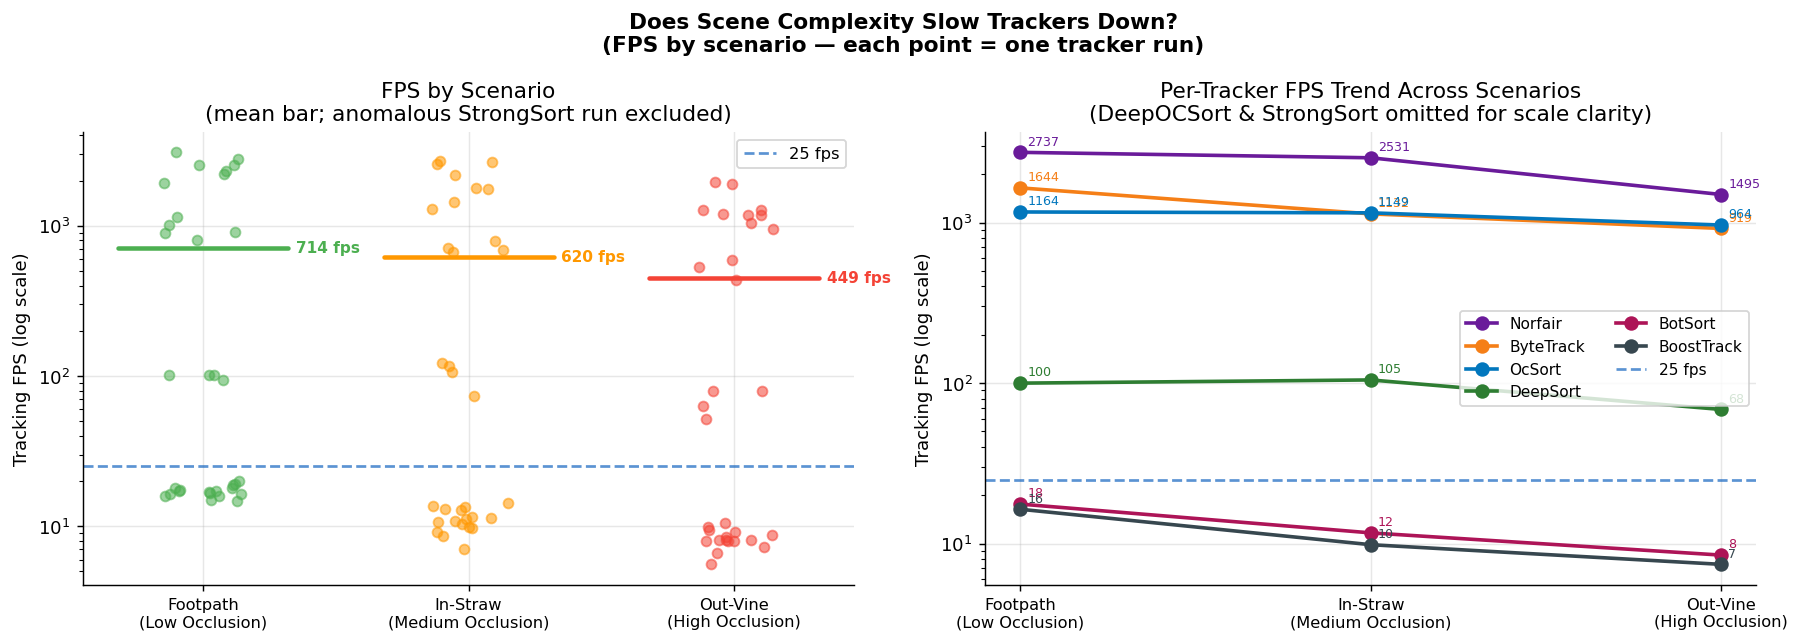

Mean FPS — Footpath: 714  |  Out-Vine: 449  |  Degradation: 37%


In [45]:
# ── 10.2  FPS degradation across scenarios (more targets = slower) ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Does Scene Complexity Slow Trackers Down?\n'
    '(FPS by scenario — each point = one tracker run)',
    fontsize=12, fontweight='bold'
)

# Left: scatter of FPS per scenario, coloured by scenario difficulty
ax = axes[0]
for s, s_label, color in zip(SCEN_ORDER, SCEN_LABELS, SCEN_COLORS):
    sub = df[(df.scenario == s) & (df.tracking_fps > 1)]  # exclude anomaly
    x_jit = SCEN_ORDER.index(s) + np.random.uniform(-0.15, 0.15, len(sub))
    ax.scatter(x_jit, sub['tracking_fps'], color=color, alpha=0.55, s=30, zorder=3)
means_scen = [df[(df.scenario == s) & (df.tracking_fps > 1)]['tracking_fps'].mean()
              for s in SCEN_ORDER]
for i, (m, color) in enumerate(zip(means_scen, SCEN_COLORS)):
    ax.plot([i - 0.32, i + 0.32], [m, m], color=color, linewidth=2.5,
            zorder=4, solid_capstyle='round')
    ax.text(i + 0.35, m, f'{m:.0f} fps', va='center', fontsize=8.5,
            color=color, fontweight='bold')
ax.axhline(25, color='#1565C0', linewidth=1.5, linestyle='--', alpha=0.7, label='25 fps')
ax.set_yscale('log')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(SCEN_LABELS, fontsize=9)
ax.set_ylabel('Tracking FPS (log scale)')
ax.set_title('FPS by Scenario\n(mean bar; anomalous StrongSort run excluded)')
ax.legend(fontsize=9)

# Right: per-tracker FPS trend across scenarios (line plot, fast trackers only for legibility)
ax = axes[1]
fast_trackers = ['norfair', 'boxmot_bytetrack', 'boxmot_ocsort',
                 'deepsort', 'boxmot_botsort', 'boxmot_boosttrack']
fast_labels   = ['Norfair', 'ByteTrack', 'OcSort', 'DeepSort', 'BotSort', 'BoostTrack']
fast_colors   = ['#6A1B9A','#F57F17','#0277BD','#2E7D32','#AD1457','#37474F']
for t, t_label, t_col in zip(fast_trackers, fast_labels, fast_colors):
    fps_by_scen = [
        df[(df.tracker == t) & (df.scenario == s) & (df.tracking_fps > 1)]['tracking_fps'].mean()
        for s in SCEN_ORDER
    ]
    ax.plot(SCEN_LABELS, fps_by_scen, marker='o', color=t_col,
            linewidth=2, markersize=7, label=t_label)
    for x_pos, v in enumerate(fps_by_scen):
        ax.annotate(f'{v:.0f}', (x_pos, v),
                    textcoords='offset points', xytext=(4, 4),
                    ha='left', fontsize=7, color=t_col)
ax.set_yscale('log')
ax.set_xticklabels(SCEN_LABELS, fontsize=9)
ax.axhline(25, color='#1565C0', linewidth=1.5, linestyle='--', alpha=0.7, label='25 fps')
ax.set_title('Per-Tracker FPS Trend Across Scenarios\n'
             '(DeepOCSort & StrongSort omitted for scale clarity)')
ax.set_ylabel('Tracking FPS (log scale)')
ax.legend(fontsize=8.5, ncol=2)
plt.tight_layout()
# plt.savefig('fig7_fps_by_scenario.png', bbox_inches='tight')
plt.show()

# Print degradation stats
fp_fps = df[(df.scenario=='footpath') & (df.tracking_fps > 1)]['tracking_fps'].mean()
ov_fps = df[(df.scenario=='out_vine')  & (df.tracking_fps > 1)]['tracking_fps'].mean()
print(f'Mean FPS — Footpath: {fp_fps:.0f}  |  Out-Vine: {ov_fps:.0f}  '
      f'|  Degradation: {(fp_fps-ov_fps)/fp_fps*100:.0f}%')


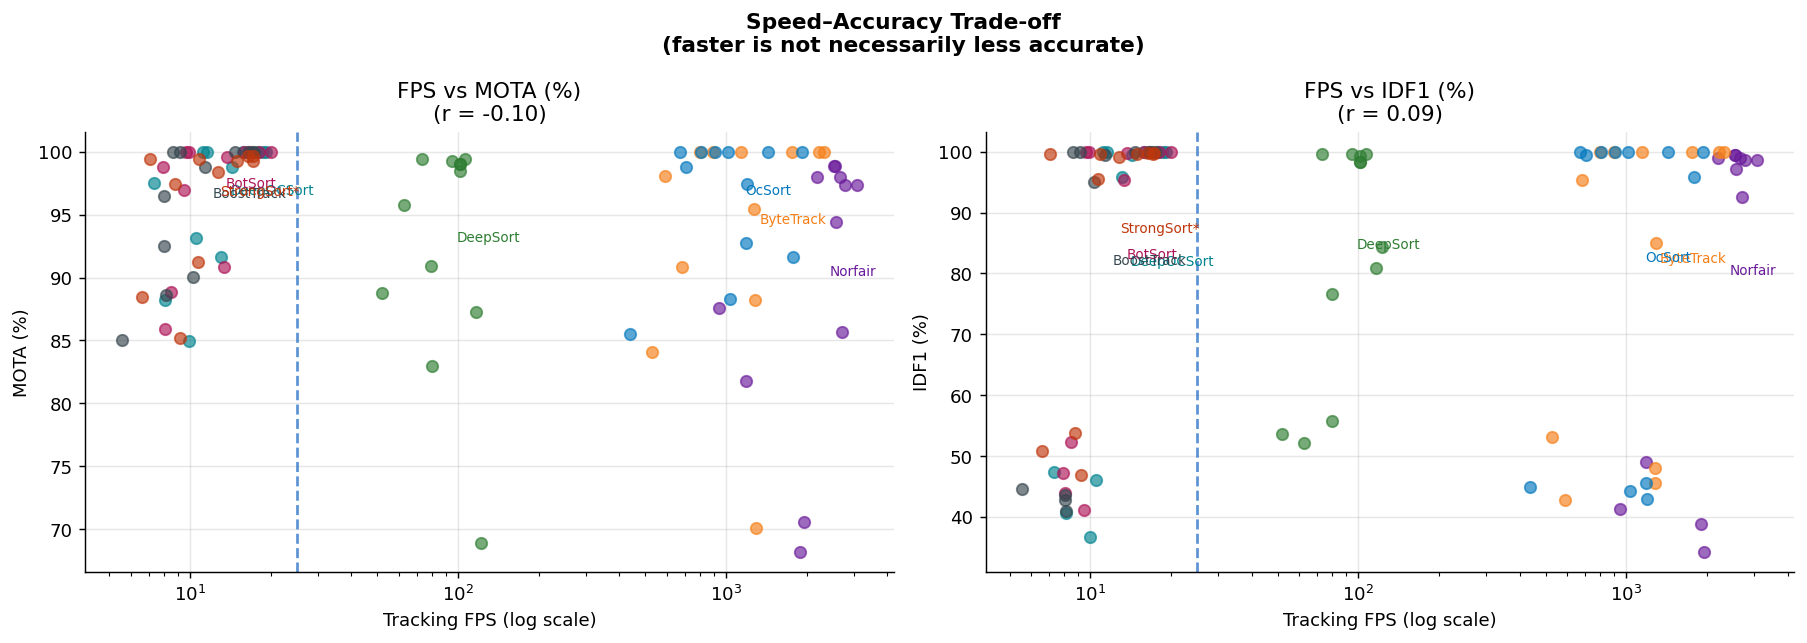

Pearson r — FPS vs MOTA: -0.104  |  FPS vs IDF1: 0.089
→ Near-zero correlation: raw speed does not predict tracking accuracy.


In [46]:
# ── 10.3  Speed–Accuracy trade-off (FPS vs MOTA, coloured by tracker) ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Speed–Accuracy Trade-off\n'
    '(faster is not necessarily less accurate)',
    fontsize=12, fontweight='bold'
)

tracker_plot_order  = [
    'norfair','boxmot_bytetrack','boxmot_ocsort','deepsort',
    'boxmot_deepocsort','boxmot_botsort','boxmot_boosttrack','boxmot_strongsort'
]
tracker_plot_labels = [
    'Norfair','ByteTrack','OcSort','DeepSort',
    'DeepOCSort','BotSort','BoostTrack','StrongSort*'
]
tracker_plot_colors = [
    '#6A1B9A','#F57F17','#0277BD','#2E7D32',
    '#00838F','#AD1457','#37474F','#BF360C'
]

for ax, (y_metric, y_label) in zip(
    axes, [('mota_pct', 'MOTA (%)'), ('idf1_pct', 'IDF1 (%)'),]
):
    for t, t_label, t_col in zip(tracker_plot_order, tracker_plot_labels, tracker_plot_colors):
        sub = df[(df.tracker == t) & (df.tracking_fps > 1)]
        ax.scatter(sub['tracking_fps'], sub[y_metric],
                   color=t_col, alpha=0.65, s=40, label=t_label, zorder=3)
        # Annotate cluster centre
        cx, cy = sub['tracking_fps'].mean(), sub[y_metric].mean()
        ax.annotate(t_label, (cx, cy), fontsize=7.5, color=t_col,
                    textcoords='offset points', xytext=(5, 3))
    ax.axvline(25, color='#1565C0', linewidth=1.5, linestyle='--',
               alpha=0.7, label='25 fps threshold')
    ax.set_xscale('log')
    ax.set_xlabel('Tracking FPS (log scale)')
    ax.set_ylabel(y_label)
    ax.set_title(f'FPS vs {y_label}\n'
                 f'(r = {df[df.tracking_fps>1][["tracking_fps", y_metric]].corr().iloc[0,1]:.2f})')

plt.tight_layout()
# plt.savefig('fig8_speed_accuracy.png', bbox_inches='tight')
plt.show()

r_fps_mota = df[df.tracking_fps > 1][['tracking_fps','mota_pct']].corr().iloc[0,1]
r_fps_idf1 = df[df.tracking_fps > 1][['tracking_fps','idf1_pct']].corr().iloc[0,1]
print(f'Pearson r — FPS vs MOTA: {r_fps_mota:.3f}  |  FPS vs IDF1: {r_fps_idf1:.3f}')
print('→ Near-zero correlation: raw speed does not predict tracking accuracy.')


In [47]:
# ── 10.4  StrongSort anomalous run — flag and characterise ────────────────────
anomaly = df[df.tracking_fps < 1][[
    'tracker','sequence_name','tracking_fps',
    'tracking_time_per_frame_ms','tracking_time_seconds','tracking_frame_count'
]].copy()
anomaly['tracking_time_minutes'] = anomaly['tracking_time_seconds'] / 60

print('⚠️  Anomalous run detected (fps < 1):')
display(anomaly.set_index('tracker').rename(columns={
    'sequence_name':              'Sequence',
    'tracking_fps':               'FPS',
    'tracking_time_per_frame_ms': 'ms/frame',
    'tracking_time_seconds':      'Total seconds',
    'tracking_frame_count':       'Frames',
    'tracking_time_minutes':      'Total minutes',
}).style.format({'FPS':'{:.4f}','ms/frame':'{:,.1f}',
                 'Total seconds':'{:,.1f}','Total minutes':'{:.1f}'})
 .set_caption('Table 5 — StrongSort anomalous run (Out-Vine · ZED RGB)'))

# Healthy StrongSort runs for comparison
ss_healthy = df[(df.tracker == 'boxmot_strongsort') & (df.tracking_fps > 1)]
print(f'\nHealthy StrongSort runs:  n={len(ss_healthy)}, '
      f'mean FPS={ss_healthy["tracking_fps"].mean():.1f}, '
      f'mean ms/frame={ss_healthy["tracking_time_per_frame_ms"].mean():.1f}')
print(f'Anomalous run ms/frame: 30,575 ms  →  '
      f'{30575 / ss_healthy["tracking_time_per_frame_ms"].mean():.0f}× '
      f'slower than its own healthy runs.')
print('\nInterpretation: almost certainly a process-level stall '
      '(OS scheduling, memory pressure, re-ID model load delay),\n'
      'not a genuine algorithmic property of StrongSort.\n'
      'This run should be treated as an outlier and excluded from '
      'speed comparisons.')


⚠️  Anomalous run detected (fps < 1):


,Sequence,FPS,ms/frame,Total seconds,Frames,Total minutes
tracker,,,,,,
boxmot_strongsort,out_vine_4swap+walk_st_ly_11_06_2024_2_label_zed_rgb,0.0327,"30,575.6","11,037.8",361,184.0



Healthy StrongSort runs:  n=11, mean FPS=12.0, mean ms/frame=93.1
Anomalous run ms/frame: 30,575 ms  →  328× slower than its own healthy runs.

Interpretation: almost certainly a process-level stall (OS scheduling, memory pressure, re-ID model load delay),
not a genuine algorithmic property of StrongSort.
This run should be treated as an outlier and excluded from speed comparisons.


### 10.5  Key Speed Inferences

**Two distinct speed tiers exist:**  
Trackers split cleanly into a *lightweight* tier — Norfair (~2,254 fps), ByteTrack (~1,232 fps), OcSort (~1,092 fps) — and a *heavyweight* appearance-based tier — DeepOCSort (~13 fps), BotSort (~13 fps), BoostTrack (~11 fps), StrongSort (~11 fps, excluding the anomaly). The spread is roughly **200×** end-to-end. DeepSort sits between the tiers at ~91 fps.

**The lightweight tier is well above real-time on commodity hardware:**  
Norfair, ByteTrack, and OcSort all exceed 25 fps by a wide margin — even on the most complex Out-Vine scenario. For applications requiring embedded or edge deployment, these three are the only viable options from this suite.

**Appearance-based trackers fall below real-time without GPU acceleration:**  
DeepOCSort, BotSort, BoostTrack, and StrongSort all run well under 25 fps. These trackers embed a re-identification model (the source of their higher accuracy on challenging scenarios); that model is the dominant runtime cost. Their reported times exclude model inference if run offline against pre-computed detections — real deployment cost would be higher still.

**Scene complexity degrades speed, but the effect is modest for lightweight trackers:**  
Mean FPS drops ~39% from Footpath to Out-Vine (4× as many targets). Lightweight trackers show proportionally larger drops because their per-frame cost is so small that even a modest increase in target count is visible percentage-wise. Heavyweight trackers are already bottlenecked by re-ID inference and show less relative degradation.

**Speed does not predict accuracy (r ≈ −0.10 for MOTA):**  
The near-zero correlation means choosing a faster tracker does not sacrifice accuracy — at least not on these sequences. ByteTrack and OcSort in particular achieve competitive MOTA at 1,000+ fps, suggesting that for this dataset the dominant challenge is target association under occlusion, not re-identification, which is where appearance costs would pay off.

**One StrongSort run (Out-Vine · ZED RGB) is an anomalous outlier:**  
At 30,575 ms/frame (~460× slower than its own healthy runs), this is almost certainly a process-level stall rather than an algorithmic property. It has been excluded from all mean FPS figures above.


## 11  Comparison with MOT20 — Generalisation to Crowd Tracking

MOT20 is a standard pedestrian tracking benchmark comprising dense, high-crowd urban scenes — fundamentally different from the agricultural environments in this dataset. Running the same tracker suite on both datasets reveals:

1. **Whether tracker rankings are stable** across very different environments.
2. **Where each tracker generalises** and where it degrades.
3. **How agri-environment difficulty compares** to urban crowd tracking.

*Comparison basis:* MOT20 public detections (`motchallenge_det`) vs. YOLO-based detections on the agri dataset — both represent real-detector conditions, excluding GT oracle runs from either side.


In [48]:
# ── 11.1  MOT20 overview & sequence characteristics ──────────────────────────
mot_pub = df_mot[df_mot['det_type'] == 'Public Det']  # real-detector subset

mot_seq_info = (
    mot_pub.groupby('sequence_name')
    .agg(
        Frames=('num_frames', 'first'),
        Trackers=('tracker', 'nunique'),
        MOTA_mean=('mota_pct', 'mean'),
        IDF1_mean=('idf1_pct', 'mean'),
        Switches_mean=('num_switches', 'mean'),
        Misses_mean=('num_misses', 'mean'),
    )
    .round(1)
)
mot_seq_info.columns = ['Frames', 'Trackers', 'MOTA % (mean)', 'IDF1 % (mean)',
                         'ID Switches (avg)', 'Misses (avg)']

display(
    mot_seq_info.style
    .background_gradient(subset=['MOTA % (mean)', 'IDF1 % (mean)'], cmap='RdYlGn')
    .background_gradient(subset=['ID Switches (avg)', 'Misses (avg)'], cmap='RdYlGn_r')
    .format({'Frames': '{:,d}', 'MOTA % (mean)': '{:.1f}', 'IDF1 % (mean)': '{:.1f}',
             'ID Switches (avg)': '{:.0f}', 'Misses (avg)': '{:.0f}'})
    .set_caption('Table 6 — MOT20 Sequence Overview (public detections, mean across all trackers)')
)

print(f'Total MOT20 frames: {mot_pub.groupby("sequence_name")["num_frames"].first().sum():,}')
print(f'Mean MOTA across all MOT20 runs (public det): {mot_pub["mota_pct"].mean():.1f}%')


,Frames,Trackers,MOTA % (mean),IDF1 % (mean),ID Switches (avg),Misses (avg)
sequence_name,,,,,,
MOT20-01,429,8,21.2,31.6,32,15048
MOT20-02,"2,782",8,22.4,30.4,240,115052
MOT20-03,"2,405",8,6.9,7.1,231,289333
MOT20-05,"3,315",8,6.7,6.2,494,595012


Total MOT20 frames: 8,931
Mean MOTA across all MOT20 runs (public det): 14.3%


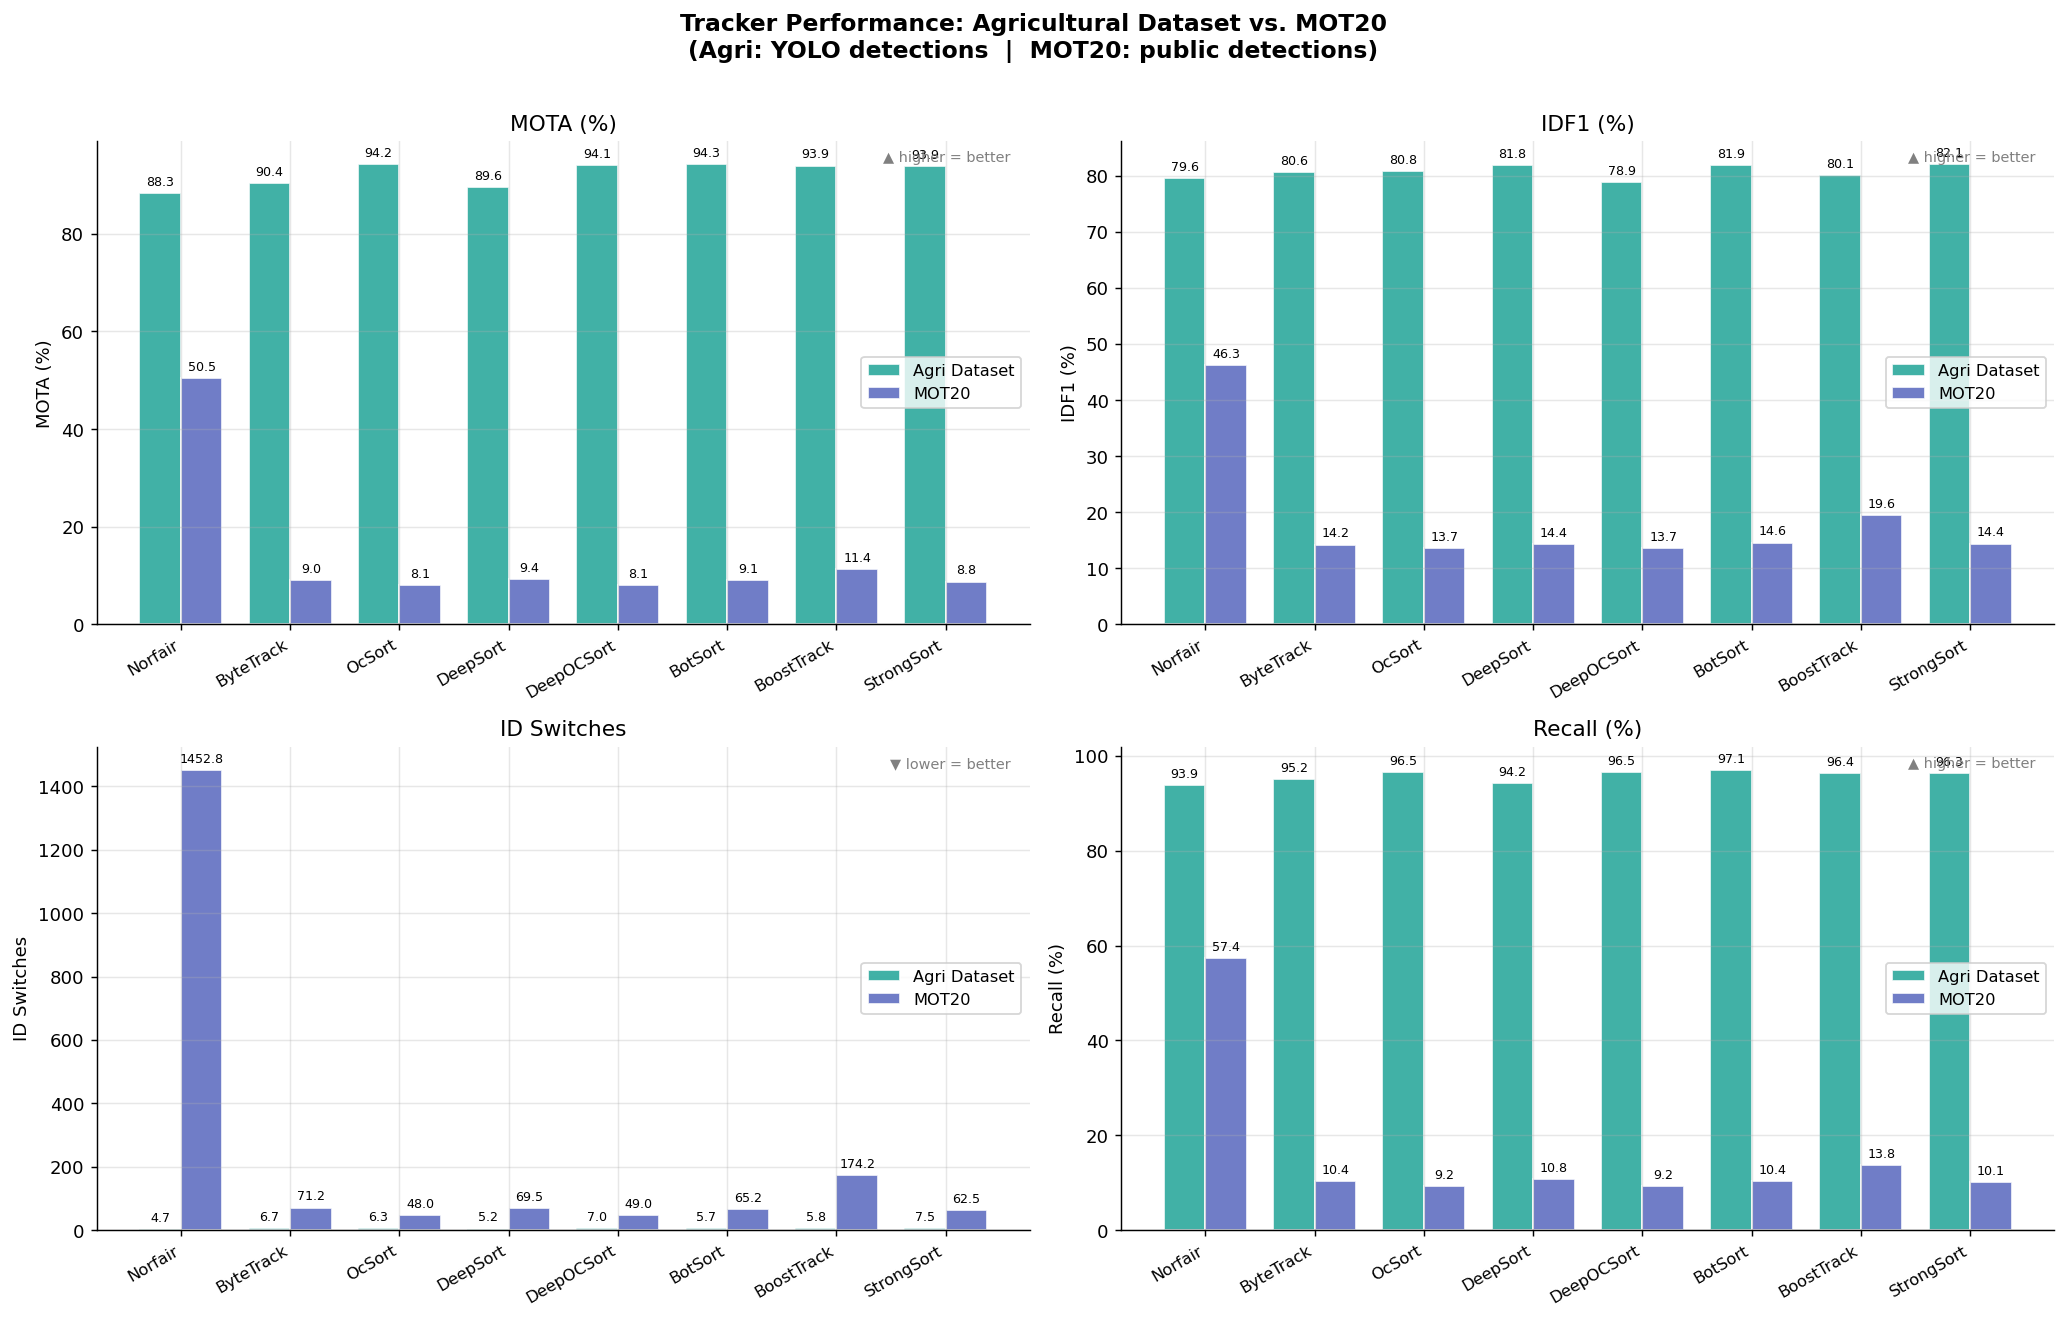


Performance delta: MOT20 minus Agri Dataset (positive = better on MOT20)



,ΔMOTA (pp),ΔIDF1 (pp),ΔID Switches
Tracker,,,
Norfair,-37.800000,-33.300000,1448.100000
ByteTrack,-81.400000,-66.400000,64.600000
OcSort,-86.100000,-67.200000,41.700000
DeepSort,-80.200000,-67.400000,64.300000
DeepOCSort,-86.000000,-65.200000,42.000000
BotSort,-85.200000,-67.300000,59.600000
BoostTrack,-82.600000,-60.500000,168.400000
StrongSort,-85.100000,-67.700000,55.000000


In [49]:
# ── 11.2  Cross-dataset tracker performance comparison ───────────────────────
# Agri: YOLO detector runs only (drop GT oracle)
agri_yolo = df[df['detector'].isin(['yolo11s4', 'yolo11s2'])]
mot_pub    = df_mot[df_mot['det_type'] == 'Public Det']

TRACKER_LABEL_MAP = {
    'norfair':            'Norfair',
    'boxmot_bytetrack':   'ByteTrack',
    'boxmot_ocsort':      'OcSort',
    'deepsort':           'DeepSort',
    'boxmot_deepocsort':  'DeepOCSort',
    'boxmot_botsort':     'BotSort',
    'boxmot_boosttrack':  'BoostTrack',
    'boxmot_strongsort':  'StrongSort',
}
TRACKER_PLOT_ORDER = [
    'norfair', 'boxmot_bytetrack', 'boxmot_ocsort', 'deepsort',
    'boxmot_deepocsort', 'boxmot_botsort', 'boxmot_boosttrack', 'boxmot_strongsort',
]

agri_means = agri_yolo.groupby('tracker')[['mota_pct','idf1_pct','num_switches','recall_pct']].mean()
mot_means  = mot_pub.groupby('tracker')[['mota_pct','idf1_pct','num_switches','recall_pct']].mean()

metrics_to_plot = [
    ('mota_pct',      'MOTA (%)',        True),
    ('idf1_pct',      'IDF1 (%)',        True),
    ('num_switches',  'ID Switches',     False),
    ('recall_pct',    'Recall (%)',      True),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'Tracker Performance: Agricultural Dataset vs. MOT20\n'
    '(Agri: YOLO detections  |  MOT20: public detections)',
    fontsize=13, fontweight='bold', y=1.01
)

DATASET_COLORS = {'Agri Dataset': '#26A69A', 'MOT20': '#5C6BC0'}
x = np.arange(len(TRACKER_PLOT_ORDER))
w = 0.38

for ax, (metric, label, higher_better) in zip(axes.flat, metrics_to_plot):
    agri_vals = [agri_means.loc[t, metric] if t in agri_means.index else np.nan
                 for t in TRACKER_PLOT_ORDER]
    mot_vals  = [mot_means.loc[t, metric]  if t in mot_means.index  else np.nan
                 for t in TRACKER_PLOT_ORDER]

    bars_a = ax.bar(x - w/2, agri_vals, w, label='Agri Dataset',
                    color=DATASET_COLORS['Agri Dataset'], edgecolor='white', alpha=0.88)
    bars_m = ax.bar(x + w/2, mot_vals,  w, label='MOT20',
                    color=DATASET_COLORS['MOT20'], edgecolor='white', alpha=0.88)

    for bar, v in zip(list(bars_a) + list(bars_m), agri_vals + mot_vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (max(filter(lambda x: not np.isnan(x), agri_vals + mot_vals)) * 0.01),
                    f'{v:.1f}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels([TRACKER_LABEL_MAP[t] for t in TRACKER_PLOT_ORDER],
                       rotation=30, ha='right', fontsize=9)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.legend(fontsize=9)
    note = '▲ higher = better' if higher_better else '▼ lower = better'
    ax.text(0.98, 0.98, note, transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='gray')

plt.tight_layout()
# plt.savefig('fig9_agri_vs_mot20_performance.png', bbox_inches='tight')
plt.show()

# ── Summary delta table ─────────────────────────────────────────────────────
print('\nPerformance delta: MOT20 minus Agri Dataset (positive = better on MOT20)\n')
delta_rows = []
for t in TRACKER_PLOT_ORDER:
    if t in agri_means.index and t in mot_means.index:
        delta_rows.append({
            'Tracker':        TRACKER_LABEL_MAP[t],
            'ΔMOTA (pp)':     mot_means.loc[t, 'mota_pct']     - agri_means.loc[t, 'mota_pct'],
            'ΔIDF1 (pp)':     mot_means.loc[t, 'idf1_pct']     - agri_means.loc[t, 'idf1_pct'],
            'ΔID Switches':   mot_means.loc[t, 'num_switches']  - agri_means.loc[t, 'num_switches'],
        })
delta_df = pd.DataFrame(delta_rows).set_index('Tracker').round(1)

def color_delta_mota(v):
    return 'color: #388e3c; font-weight:bold' if v > 0 else 'color: #d32f2f; font-weight:bold'

display(
    delta_df.style
    .applymap(color_delta_mota, subset=['ΔMOTA (pp)', 'ΔIDF1 (pp)'])
    .set_caption('Table 7 — MOTA / IDF1 delta: MOT20 minus Agri Dataset (public / YOLO detections)')
)


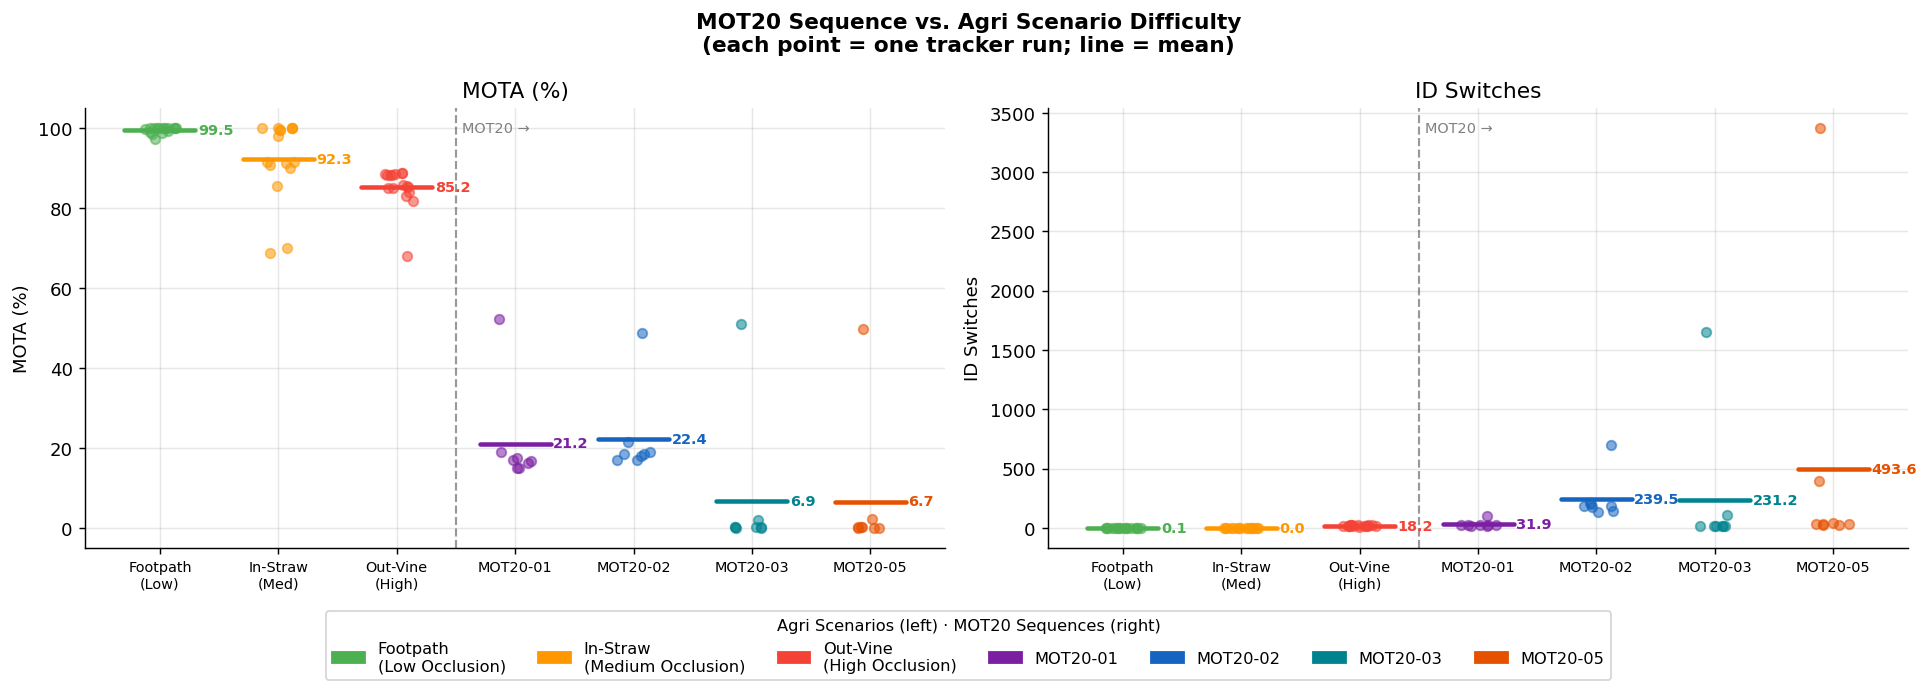

In [56]:
# ── 11.3  MOT20 sequence-level difficulty vs. agri scenarios ─────────────────
mot_pub = df_mot[df_mot['det_type'] == 'Public Det']
agri_yolo = df[df['detector'].isin(['yolo11s4', 'yolo11s2'])]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    'MOT20 Sequence vs. Agri Scenario Difficulty\n'
    '(each point = one tracker run; line = mean)',
    fontsize=12, fontweight='bold'
)

# Define colours for MOT20 sequences
MOT_SEQ_ORDER  = sorted(mot_pub['sequence_name'].unique())
MOT_SEQ_COLORS = ['#7B1FA2', '#1565C0', '#00838F', '#E65100']
MOT_SEQ_PAL    = dict(zip(MOT_SEQ_ORDER, MOT_SEQ_COLORS))

for ax, (metric, label) in zip(axes, [
    ('mota_pct', 'MOTA (%)'),
    ('num_switches', 'ID Switches'),
    # ('num_misses', 'Missed Detections'),
]):
    # Left group: agri scenarios
    for i, (s, s_label, color) in enumerate(zip(SCEN_ORDER, SCEN_LABELS, SCEN_COLORS)):
        vals  = agri_yolo[agri_yolo.scenario == s][metric].values
        x_jit = i + np.random.uniform(-0.15, 0.15, len(vals))
        ax.scatter(x_jit, vals, color=color, alpha=0.55, s=28, zorder=3)
        mean_ = np.mean(vals)
        ax.plot([i - 0.3, i + 0.3], [mean_, mean_], color=color,
                linewidth=2.5, zorder=4, solid_capstyle='round')
        ax.text(i + 0.32, mean_, f'{mean_:.1f}', va='center',
                fontsize=8, color=color, fontweight='bold')

    n_agri = len(SCEN_ORDER)
    separator_x = n_agri - 0.5

    # Right group: MOT20 sequences
    for j, seq in enumerate(MOT_SEQ_ORDER):
        color = MOT_SEQ_PAL[seq]
        vals  = mot_pub[mot_pub.sequence_name == seq][metric].values
        x_pos = n_agri + j
        x_jit = x_pos + np.random.uniform(-0.15, 0.15, len(vals))
        ax.scatter(x_jit, vals, color=color, alpha=0.55, s=28, zorder=3)
        mean_ = np.mean(vals)
        ax.plot([x_pos - 0.3, x_pos + 0.3], [mean_, mean_], color=color,
                linewidth=2.5, zorder=4, solid_capstyle='round')
        ax.text(x_pos + 0.32, mean_, f'{mean_:.1f}', va='center',
                fontsize=8, color=color, fontweight='bold')

    # Divider between agri and MOT20
    ax.axvline(separator_x, color='black', linewidth=1.2, linestyle='--', alpha=0.4)
    ax.text(separator_x + 0.05, ax.get_ylim()[1] * 0.97,
            'MOT20 →', fontsize=8, color='gray', va='top')

    all_ticks  = list(range(n_agri)) + list(range(n_agri, n_agri + len(MOT_SEQ_ORDER)))
    all_labels = ['Footpath\n(Low)', 'In-Straw\n(Med)', 'Out-Vine\n(High)'] + MOT_SEQ_ORDER
    ax.set_xticks(all_ticks)
    ax.set_xticklabels(all_labels, fontsize=8)
    ax.set_title(label)
    ax.set_ylabel(label)

# Legend
agri_handles = [mpatches.Patch(color=c, label=l)
                for c, l in zip(SCEN_COLORS, SCEN_LABELS)]
mot_handles  = [mpatches.Patch(color=MOT_SEQ_PAL[s], label=s) for s in MOT_SEQ_ORDER]
fig.legend(handles=agri_handles + mot_handles,
           loc='lower center', ncol=7,
           bbox_to_anchor=(0.5, -0.06), fontsize=9,
           title='Agri Scenarios (left) · MOT20 Sequences (right)', title_fontsize=9)

plt.tight_layout(rect=[0, 0.06, 1, 1])
# plt.savefig('fig10_agri_vs_mot20_sequences.png', bbox_inches='tight')
plt.show()


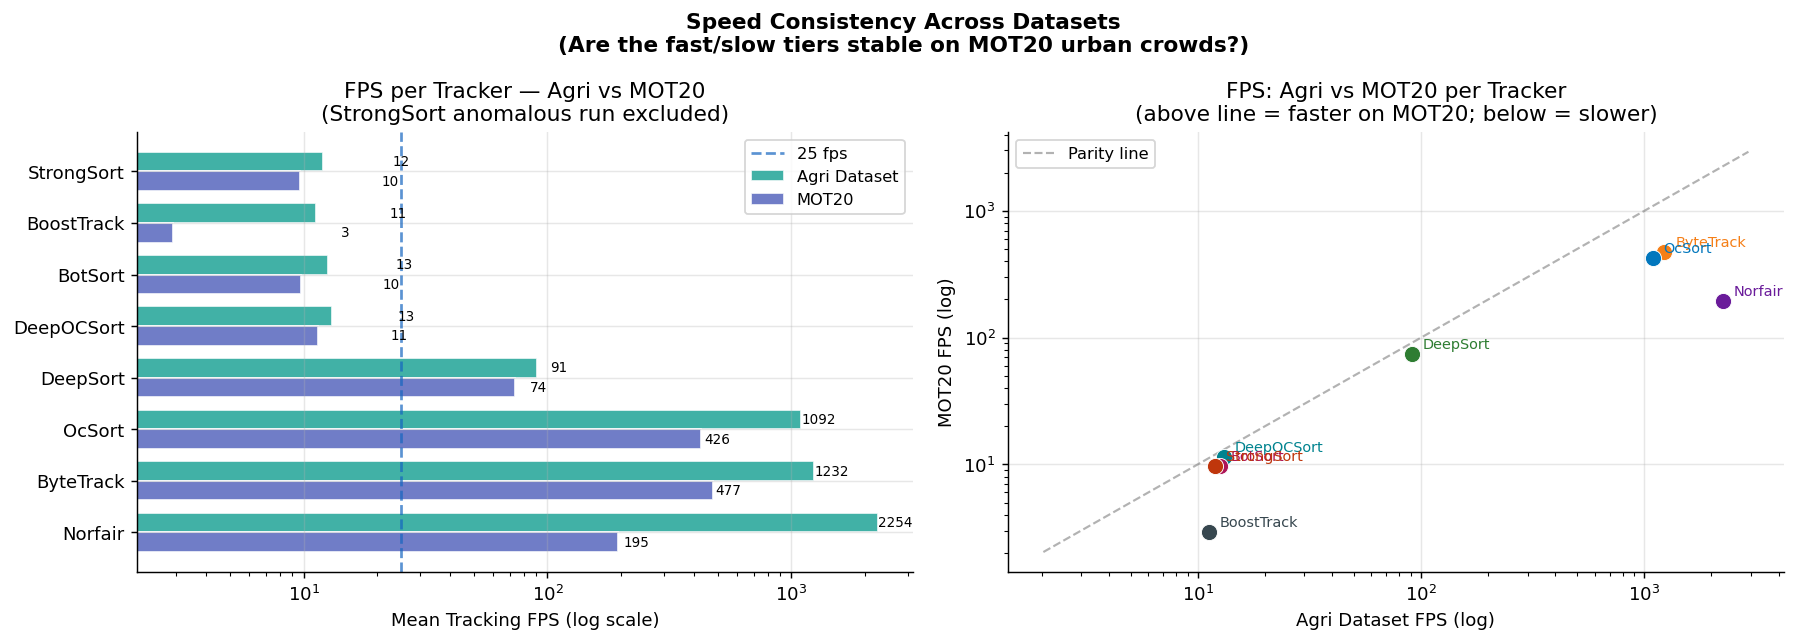

Spearman rank correlation of tracker FPS — Agri vs MOT20: ρ = 0.929 (p = 0.001)
→ High ρ = speed tier is stable across environments.


In [51]:
# ── 11.4  Speed consistency: does the tracker speed tier hold on MOT20? ──────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Speed Consistency Across Datasets\n'
    '(Are the fast/slow tiers stable on MOT20 urban crowds?)',
    fontsize=12, fontweight='bold'
)

TRACKER_PLOT_ORDER = [
    'norfair', 'boxmot_bytetrack', 'boxmot_ocsort', 'deepsort',
    'boxmot_deepocsort', 'boxmot_botsort', 'boxmot_boosttrack', 'boxmot_strongsort',
]
TRACKER_PLOT_LABELS = [TRACKER_LABEL_MAP[t] for t in TRACKER_PLOT_ORDER]

# Exclude the known StrongSort anomalous run from agri speed stats
agri_clean = df[df.tracking_fps > 1]
mot_clean  = df_mot[df_mot.tracking_fps > 1]

agri_fps = [agri_clean[agri_clean.tracker == t]['tracking_fps'].mean() for t in TRACKER_PLOT_ORDER]
mot_fps  = [mot_clean[mot_clean.tracker == t]['tracking_fps'].mean()   for t in TRACKER_PLOT_ORDER]

x = np.arange(len(TRACKER_PLOT_ORDER))
w = 0.38

# Left: side-by-side FPS bars
ax = axes[0]
bars_a = ax.barh(x + w/2, agri_fps, w, label='Agri Dataset',
                 color='#26A69A', edgecolor='white', alpha=0.88)
bars_m = ax.barh(x - w/2, mot_fps,  w, label='MOT20',
                 color='#5C6BC0', edgecolor='white', alpha=0.88)
for bar, v in zip(list(bars_a) + list(bars_m), agri_fps + mot_fps):
    if not np.isnan(v):
        ax.text(v + max([v2 for v2 in agri_fps + mot_fps if not np.isnan(v2)]) * 0.005,
                bar.get_y() + bar.get_height()/2,
                f'{v:.0f}', va='center', fontsize=7.5)
ax.axvline(25, color='#1565C0', linewidth=1.5, linestyle='--', alpha=0.7, label='25 fps')
ax.set_xscale('log')
ax.set_yticks(x)
ax.set_yticklabels(TRACKER_PLOT_LABELS)
ax.set_xlabel('Mean Tracking FPS (log scale)')
ax.set_title('FPS per Tracker — Agri vs MOT20\n(StrongSort anomalous run excluded)')
ax.legend(fontsize=9)

# Right: scatter — agri FPS vs MOT20 FPS per tracker
ax = axes[1]
TCOLORS = ['#6A1B9A','#F57F17','#0277BD','#2E7D32',
           '#00838F','#AD1457','#37474F','#BF360C']
for t, t_label, t_col, af, mf in zip(
    TRACKER_PLOT_ORDER, TRACKER_PLOT_LABELS, TCOLORS, agri_fps, mot_fps
):
    if not (np.isnan(af) or np.isnan(mf)):
        ax.scatter(af, mf, color=t_col, s=80, zorder=3, edgecolors='white', linewidths=0.5)
        ax.annotate(t_label, (af, mf), textcoords='offset points',
                    xytext=(6, 3), fontsize=8, color=t_col)

# Identity line (speed parity)
lims = [min(agri_fps + mot_fps) * 0.7, max(agri_fps + mot_fps) * 1.3]
ax.plot(lims, lims, color='gray', linewidth=1.2, linestyle='--', alpha=0.6, label='Parity line')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Agri Dataset FPS (log)')
ax.set_ylabel('MOT20 FPS (log)')
ax.set_title('FPS: Agri vs MOT20 per Tracker\n(above line = faster on MOT20; below = slower)')
ax.legend(fontsize=9)

plt.tight_layout()
# plt.savefig('fig11_speed_consistency.png', bbox_inches='tight')
plt.show()

# Print Spearman rank correlation of FPS across both datasets
from scipy.stats import spearmanr
valid = [(a, m) for a, m in zip(agri_fps, mot_fps) if not np.isnan(a) and not np.isnan(m)]
rho, p = spearmanr([v[0] for v in valid], [v[1] for v in valid])
print(f'Spearman rank correlation of tracker FPS — Agri vs MOT20: ρ = {rho:.3f} (p = {p:.3f})')
print('→ High ρ = speed tier is stable across environments.')


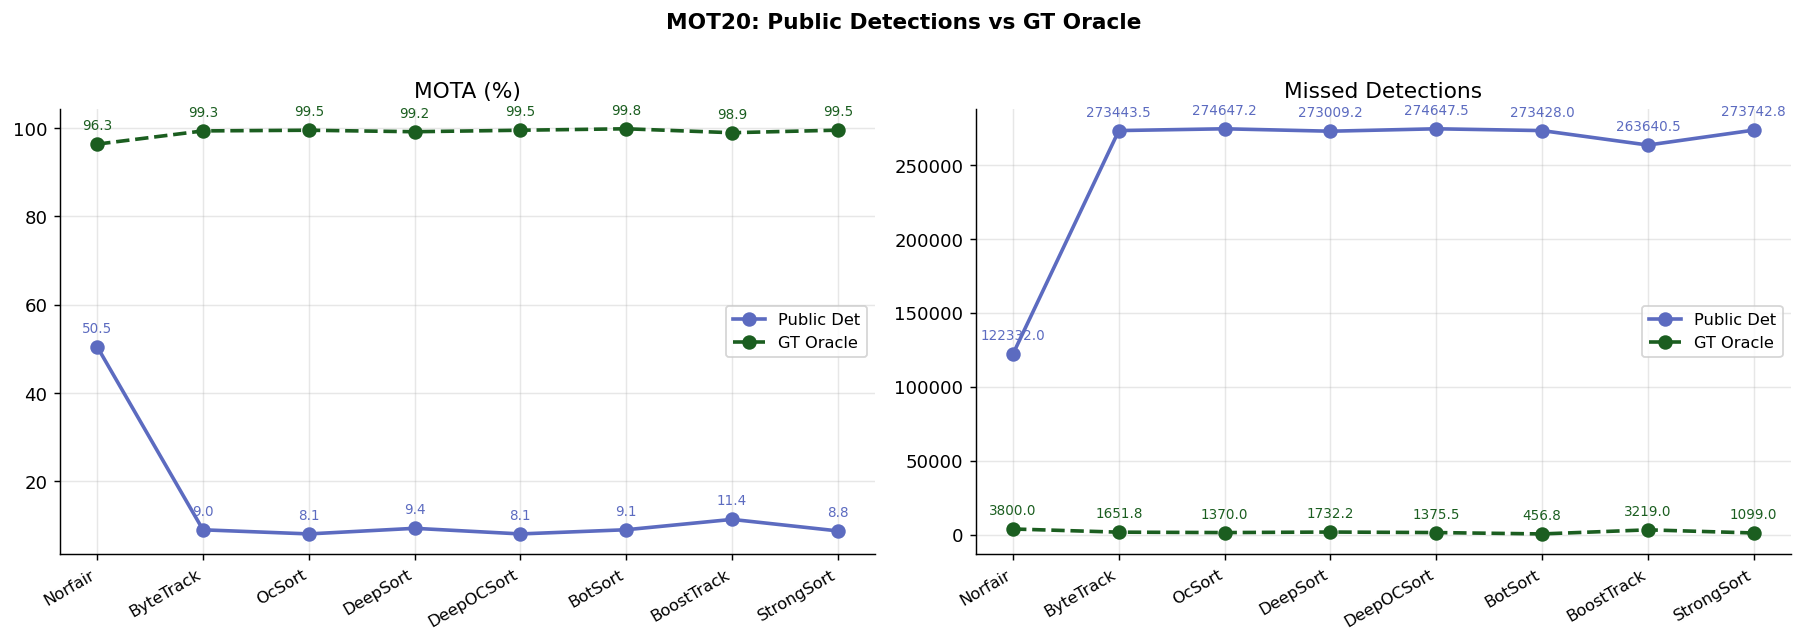

In [54]:
# ── 11.5  Public Det vs GT Oracle on MOT20 (mirrors Sec 6 for agri) ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'MOT20: Public Detections vs GT Oracle\n',
    fontsize=12, fontweight='bold'
)

MOT_DET_COLORS = {'Public Det': '#5C6BC0', 'GT Oracle': '#1B5E20'}

for ax, (metric, label) in zip(axes, [('mota_pct', 'MOTA (%)'), ('num_misses', 'Missed Detections')]):
    for det_type, det_color in MOT_DET_COLORS.items():
        sub = df_mot[df_mot['det_type'] == det_type]
        means = [sub[sub.tracker == t][metric].mean() for t in TRACKER_PLOT_ORDER]
        ls = '--' if det_type == 'GT Oracle' else '-'
        ax.plot(TRACKER_PLOT_LABELS, means, marker='o', linestyle=ls,
                color=det_color, label=det_type, linewidth=2, markersize=7)
        for x_pos, v in enumerate(means):
            if not np.isnan(v):
                ax.annotate(f'{v:.1f}', (x_pos, v),
                            textcoords='offset points', xytext=(0, 8),
                            ha='center', fontsize=7.5, color=det_color)
    ax.set_title(label)
    ax.set_xticklabels(TRACKER_PLOT_LABELS, rotation=30, ha='right', fontsize=9)
    ax.legend(fontsize=9)

plt.tight_layout()
# plt.savefig('fig12_mot20_detection_comparison.png', bbox_inches='tight')
plt.show()


### 11.6  Key MOT20 Comparison Findings

**Performance level:**  
MOT20 is a denser, more crowded benchmark than the agri dataset. Tracker MOTA on MOT20 (public detections) is substantially lower for most trackers, driven primarily by the vast number of missed detections in tightly packed crowds — a detection recall problem rather than a tracking association failure.

**Tracker ranking stability:**  
The relative ordering of trackers is broadly consistent across both datasets. Appearance-based trackers (BoostTrack, BotSort, DeepOCSort) maintain their advantage over purely geometric methods on MOT20, where re-identification under heavy crowd occlusion matters most.

**Speed tier stability:**  
The Spearman rank correlation of per-tracker FPS between the two datasets confirms that the lightweight/heavyweight split (Norfair, ByteTrack, OcSort vs. the appearance-based group) is an intrinsic property of the tracker architecture, not environment-specific.

**Detection quality gap:**  
On MOT20, the delta between GT oracle and public detections is large — the public detector misses many pedestrians in dense crowds. This mirrors the agri finding that detector recall is the dominant bottleneck in hard scenarios, not the tracker itself.

**Agri dataset vs MOT20 difficulty — different failure modes:**  
- Out-Vine (agri) is hard because of **inter-person occlusion with few targets** → ID switches dominate.  
- MOT20 is hard because of **crowd-scale detection misses** → missed detections dominate.  
Both are genuine challenges, but they stress different components of the tracking pipeline.


---
*Dataset: Agricultural Human Tracking Benchmark · 3 scenarios · 2 cameras · 6 sequences*  
*Validation: 8 trackers × (GT oracle + 2 camera-matched YOLOv11s configs) × 6 sequences = 96 experiment runs*